# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb and fit-observables.ipynb, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import seaborn as sns

import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-vary_b_I"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

full_sim_data = pd.read_pickle(d_mean)
# with pd.option_context('display.max_columns', None):
#     display(use_sim_data)

## 1. Performance-based evaluation of immune networks

In [3]:
# Create additional variables
module_reg = {'$N \longrightarrow N^*$': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$N^* \longrightarrow E$': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              '$E \longrightarrow \emptyset$': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}
module_reg_labels = {'$N \longrightarrow N^*$': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['$N \longrightarrow N^*$']], 
                     '$N^* \longrightarrow E$': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['$N^* \longrightarrow E$']],
                     '$E \longrightarrow \emptyset$': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['$E \longrightarrow \emptyset$']]}

signal_classes = [r for i, r in enumerate(["Ag. sens.", "Inflam. sens.", "Anti-inflam. sens.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]
stim_vars = ['stim_pI', 'stim_pHI', 'stim_pHE']

# if "full" in comment or "sparse" in comment:
reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
module_labels = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow \emptyset$']

opt_vars = ['psi_I', 'psi_HI', 'psi_HE', 'g0_Na', 'g0_NE', 'g0_Edie'] #, reg_bl[2]]
opt_vars_labels = [r"$\psi_{Ag}$",
                   r"$\psi_{I}$",
                   r"$\psi_{E}$",
                   r"$g_{0,N \to N^*}$,"+'\n'+r"$g_{0,E \to 2E}$",
                   r"$g_{0,N^* \to E}$",
                   r"$g_{0,E \to \emptyset}$"]

num_categories = len(perf_labels)
reg_markers = ['o', 's', 'v', '^', 'X','*', 'D','>', '<']
num_modules = len(module_labels)
num_psis = len(Na_reg)

cmap_colors = sns.color_palette("tab10") #['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
perf_var_colors = ['green', 'black', 'red', 'yellow']
intercept_vars = ['intercept_Na', 'intercept_NE', 'intercept_EE']

plots = [vir_vars[1], 'R_0']
plot_labels = [r"Immunogenicity, $\kappa$", "Reproduction\n number, $R_0$"]
short_plot_labels = [r"$\kappa$", r"$R_0$"]

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# helper variables
n_virs = len(infection_scenarios)
del infection_scenarios

### (a) Dependence of performance on individual signals

In [4]:
keep_vars = opt_vars + perf_vars + vir_vars + reg_bl + ['frac_cM', 'max_pE','T_pE_start', 'T_pE_max', 'T_pE_end','stim_pI', 'stim_pHI', 'stim_pHE','E_end', 'R_0', 'feedback']
use_sim_data = full_sim_data.loc[full_sim_data.K_H == K_H].copy()
use_sim_data.loc[:, 'R_0'] = use_sim_data['S_0']*use_sim_data['b_I']/use_sim_data['d_I'] - 1
use_sim_data.loc[:, opt_vars[0:3]] = use_sim_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
use_sim_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-use_sim_data[reg_bl].values))
use_sim_data.loc[:, 'feedback'] = np.round(np.amax(np.abs(use_sim_data[opt_vars[0:3]]), axis = 1), 2)
use_sim_data.loc[:, 'idx'] = use_sim_data.groupby(plots).ngroup()

del full_sim_data

### (c) Performance of the immune response in different contexts

In [5]:
# Visualize optimal regulation
size = 2500/np.cbrt(n_virs)

import heapq
infections_params = use_sim_data.groupby(vir_vars, as_index = False).mean()

highK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])

highK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
midK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
lowK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])

highK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])

quadrants = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[midK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[midK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[midK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])

quadrants_small = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0]
                      ])


quadrants_labels = x = ['Low ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', slow '+short_plot_labels[1],]

### (d) Dependence of performance on modules and architectures

In [6]:
# Define utility and constraint functions

num_cpu = 100

linestyles = ['-','--','-','-.',':','--', '-.']

def sample_3d_simplex(weights = [1,1,1], pnts = 100):
    """Samples points uniformly from the 3D simplex."""
    x = np.random.dirichlet(weights, pnts)
    
    return x

def grid_search(input, type = "global", vars = perf_vars[0:3], top = 0.05):

    df_list = []
    input.loc[:,opt_vars[0]] = input['psi_NE_I']
    input.loc[:,opt_vars[1]] = input['psi_NE_HI']
    input.loc[:,opt_vars[2]] = input['psi_NE_HE']
    data = input #.groupby(opt_vars, as_index = False).mean()
    
    if type == "global":
        for i, perf in enumerate(vars):
            data_sorted = data.sort_values(by=perf, ascending= True)
            max_row = data_sorted.loc[data_sorted[perf] <= (1 + top)*np.amin(data_sorted[perf])].mean() #.head(top).mean()
            max_row.loc['perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])

    elif type == "ablate":
        for i, perf in enumerate(vars):
            for j, p in enumerate(opt_vars):
                for (_, g) in data.groupby(p, as_index = False):
                    g_sorted = g.sort_values(by=perf, ascending= True)
                    max_row = g_sorted.loc[g_sorted[perf] <= (1 + top)*np.amin(g_sorted[perf])].mean() #g_sorted.head(top).mean()
                    max_row.loc['perf_index'] = i
                    max_row.loc['ablate_index'] = j
                    df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index', 'ablate_index'])
        
    return out

In [7]:
# # Create effector trajectory variables
# avg_sim_data = use_sim_data.loc[(use_sim_data['b_I'].values > 0.0)*(use_sim_data.d_I > d_S)].groupby(opt_vars, as_index = False).mean()
# avg_sim_data.loc[:,'exp_rate'] = np.log(avg_sim_data['max_pE']/max_Na)/np.maximum(avg_sim_data['T_pE_max'] - avg_sim_data['T_pE_start'], t_cycle)
# avg_sim_data.loc[:,'end_rate'] = -np.log(avg_sim_data['max_pE']/avg_sim_data['N_0'])/np.maximum(avg_sim_data['T_pE_end'] - avg_sim_data['T_pE_max'], t_cycle)
# avg_sim_data.loc[:,'max_exp'] = avg_sim_data['max_pE']/avg_sim_data['N_0']

# dyn_vars_for_dim = opt_vars + ['peff_scaled_total_harm', 'feedback', 'T_pE_start', 'exp_rate', 'end_rate', 'max_exp']
# dyn_labels_for_dim = opt_vars_labels + ['Harm', 'Feedback'] + ['Activation time\n [day]', 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Contraction rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Effector exp.\n'+ r'[$N_0$]']

# fig, axs = plt.subplots(2,len(opt_vars), figsize = (15,4.5), dpi=300, sharex = True, sharey = True)

# for k, ax in enumerate(axs.flat):
#     z = avg_sim_data[dyn_vars_for_dim[k]]
#     range = np.amax(np.abs(z))
#     im = ax.hexbin(avg_sim_data.peff_infection/avg_sim_data.harm_pI_noprotection, avg_sim_data.peff_toxicity/avg_sim_data.harm_pI_noprotection,
#                        gridsize = 50, C = z, linewidths = 0.0,
#                    cmap= 'coolwarm_r' if k < 3 else 'Reds',# alpha = 0.8,
#                    norm= mpl.colors.Normalize(vmin = -range if k < 3 else 0.0, vmax = range))
#                    #norm= mpl.colors.LogNorm() if 'time' in dyn_labels_for_dim[k] else (mpl.colors.Normalize(vmin = -range, vmax = range) if k < 6 else mpl.colors.Normalize()) )

#     #ax.set_title(dyn_labels_for_dim[k], fontsize = 7.5)
#     ax.set_xlabel("Scaled infection,\n"+r'$\tilde{H}_{inf.}^{min.}$', fontsize = 10)
#     ax.set_ylabel("Scaled toxicity,\n"+r'$\tilde{H}_{toxic.}^{min.}$', fontsize = 10)
#     ax.set_box_aspect(1)
#     ax.minorticks_off()
#     ax.locator_params(axis='y', nbins=4)
#     ax.locator_params(axis='x', nbins=4)
#     ax.xaxis.set_tick_params(labelbottom=True)
#     ax.yaxis.set_tick_params(labelleft=True)
#     cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.025)
#     cb.set_label(dyn_labels_for_dim[k], fontsize = 7)
#     cb.ax.tick_params(labelsize=6)

# fig.subplots_adjust(wspace=.6, hspace=0.55)

# plt.savefig('_figs/'+comment+'-'+'-reg-average_clear_tox'+'.pdf', dpi=150, format="pdf", transparent=True, bbox_inches="tight")

#### Optimize $[\text{Infection harm}]$

/tmp/ipykernel_38076/208386365.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_38076/208386365.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_38076/208386365.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

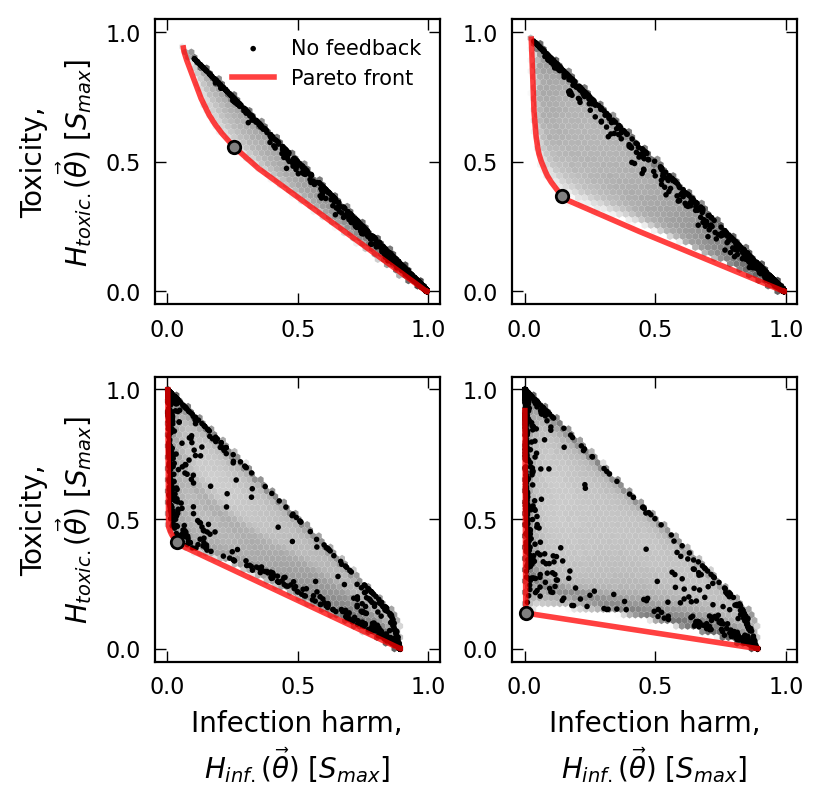

In [8]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2
kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(2, 2, 
                          figsize=(4, 4), sharex=True, sharey=True, layout='constrained')

lambdas = np.linspace(0,1,21)

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    z_label = r"Scaled Harm"

    y, x = k % 2, k // 2
    
    axs[x,y].hexbin(data.peff_infection, data.peff_toxicity,
                       gridsize = 40, C = None,
                         cmap='Grays', edgecolors = 'None',
                   norm = mpl.colors.LogNorm())
    # axs[x,y].scatter(data.peff_infection, data.peff_toxicity,
    #               s = 2, color = "gray",
    #               label = 'with feedback',
    #               edgecolors = 'None')

    no_fbk = np.sum(np.abs(data[opt_vars[0:3]]), axis = 1) == 0
    axs[x,y].scatter(data.loc[no_fbk].peff_infection, data.loc[no_fbk].peff_toxicity,
                      s = 4, color = "black",
                      label = 'No feedback',
                      edgecolors = 'None')
    pareto_designs = []
    
    for l in lambdas:
        data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
        data_sorted = data.sort_values(by='compromise', ascending= True).copy()
        max_row = data_sorted.head(10).mean()
        pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

    axs[x,y].plot(pareto_design_df['peff_infection'].values, 
                  pareto_design_df['peff_toxicity'].values,
                  color='red', linewidth = 2.0, alpha = 0.75,
                  label = 'Pareto front')

    axs[x,y].scatter(pareto_design_df['peff_infection'].values[int(len(lambdas)/2)], 
                     pareto_design_df['peff_toxicity'].values[int(len(lambdas)/2)],
                     s = 20,
                     color='grey', edgecolors = 'black', zorder = 2)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=8)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)
    
axs[0,0].legend(fontsize=7.5)

for j, ax in enumerate(axs.flat):
    if j // 2 == 1:
        ax.set_xlabel("Infection harm,\n"+r'$H_{inf.}(\vec{\theta})$ [$S_{max}$]', fontsize = 10)
    if j % 2 == 0:
        ax.set_ylabel("Toxicity,\n"+r'$H_{toxic.}(\vec{\theta})$ [$S_{max}$]', fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    #ax.set_title(quadrants_labels[j], fontsize = 8.0, pad = 2.5)

plt.savefig('_figs/fig3_'+comment+'-reg-singles_clear_tox'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

##### Minimize Harm for each infection

In [9]:
# Find optimal designs for each infection by grid searching
grid_opt = pd.concat(Parallel(n_jobs = num_cpu,
                          batch_size = 1)(delayed(grid_search)(g, top = 0.05)
                                                   for (_, g) in use_sim_data.groupby(vir_vars)
                                                  ))

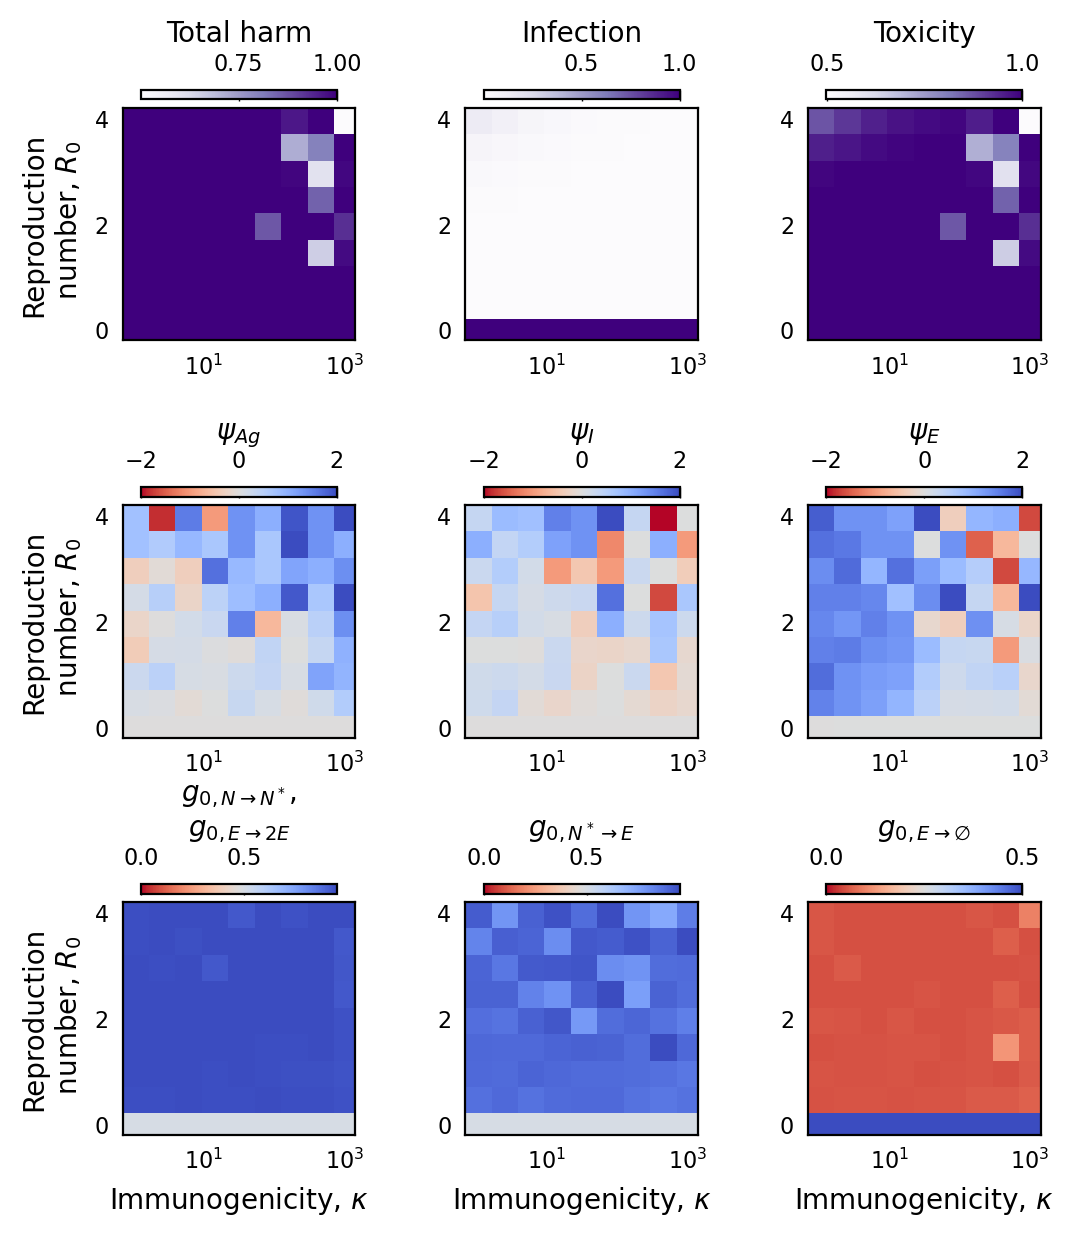

In [10]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 1)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_clearance_feedback_reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

/tmp/ipykernel_38076/3464473916.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_input.loc[:,'raw_cluster'] = clustering.labels_
/tmp/ipykernel_38076/3464473916.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_input.loc[:,'phase_cluster'] = np.array([assign_phase.loc[assign_phase.raw_cluster == p].index.tolist()[0] for p in cluster_input.raw_cluster.values]) #clustering.labels_
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are 

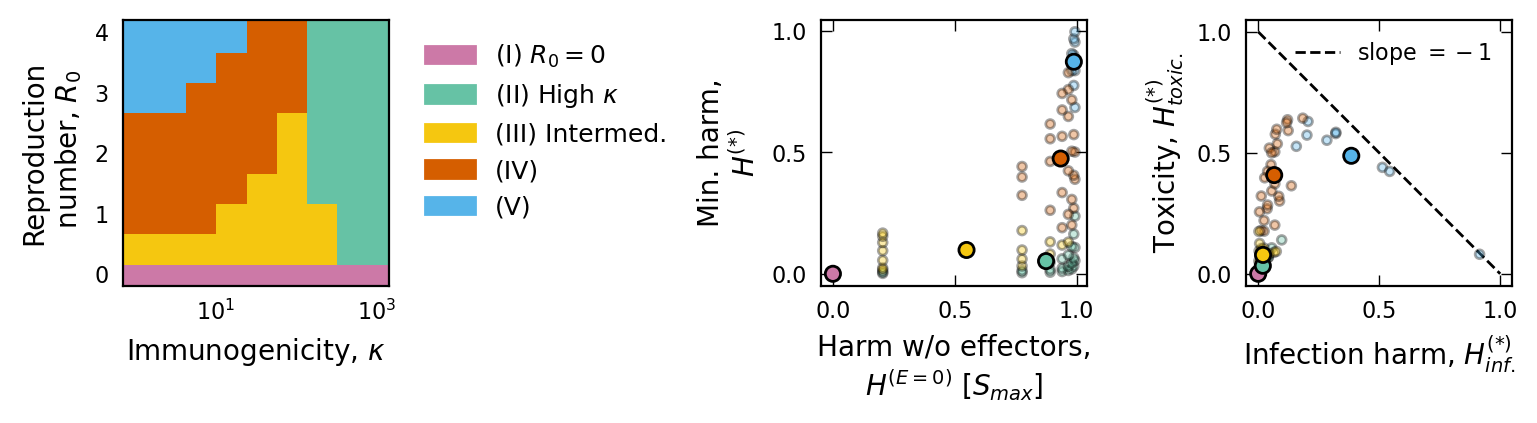

In [11]:
fig, axs = plt.subplots(1, 3, 
                          figsize=(7.75, 2), sharex=False, sharey=False, constrained_layout=True)

size = 1000/np.cbrt(n_virs)
cluster_colors = ['#CC79A7', '#66c2a5', '#F5C710', '#D55E00', '#56B4E9', 'grey', cmap_colors[-3]]

cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)]
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars + ['peff_infection', 'peff_toxicity']].values) # ['K_I', plots[1]]
for_clustering = scaler.transform(cluster_input[opt_vars + ['peff_infection', 'peff_toxicity']].values) # ['K_I', plots[1]]
clustering = KMeans(n_clusters=5, n_init = 10,
        random_state=0).fit(for_clustering)

cluster_input.loc[:,'raw_cluster'] = clustering.labels_
assign_phase = cluster_input.groupby(['raw_cluster'], 
                                     as_index = False).min().sort_values(by=plots, 
                                                                          ascending= True).reset_index()[plots + ['raw_cluster']]
cluster_input.loc[:,'phase_cluster'] = np.array([assign_phase.loc[assign_phase.raw_cluster == p].index.tolist()[0] for p in cluster_input.raw_cluster.values]) #clustering.labels_

## Make plots
# (a) Plot infection clusters
axs[0].scatter(S_0/cluster_input[plots[0]], cluster_input[plots[1]],
                 marker ='s', s = size, 
                c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values], 
                 edgecolors = 'None')

axs[0].set_xlabel(plot_labels[0], fontsize = 10)
axs[0].set_ylabel(plot_labels[1], fontsize = 10)
axs[0].semilogx()

legend_handles = []
phase_clusters = np.unique(cluster_input['phase_cluster'].values)
phase_cluster_labels = [r"(I) $R_0 = 0$", r"(II) High $\kappa$", r"(III) Intermed.", r"(IV)",  r"(V)"] #, '(VI)']
n_clusters = len(phase_clusters)
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

axs[0].legend(handles=legend_handles, bbox_to_anchor=(1.05, 1.0), fontsize=9, framealpha=0, ncol = 1)

# (b) Plot optimized and unoptimized harm
plot_data = cluster_input.groupby('phase_cluster', as_index = False).mean()

axs[1].scatter(plot_data.harm_pI_noprotection, 
               plot_data.peff_total_harm,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[1].scatter(cluster_input.harm_pI_noprotection, 
               cluster_input.peff_total_harm,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.35)

# axs[1].plot(np.linspace(0,1), np.linspace(0,1), color = 'black', linestyle = '--', zorder = 0, label=r'slope $= 1$')
axs[1].locator_params(axis='x', nbins=4)
axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(fontsize = 8)
axs[1].set_xlabel("Harm w/o effectors,\n"+r'$H^{(E = 0)}$ [$S_{max}$]', fontsize = 10)
axs[1].set_ylabel("Min. harm,\n"+r'$H^{(*)}$', fontsize = 10)

# (c) Plot optimized infection and toxicity
axs[2].scatter(plot_data.peff_infection, #/plot_data.harm_pI_noprotection, 
               plot_data.peff_toxicity, #/plot_data.harm_pI_noprotection,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[2].scatter(cluster_input.peff_infection, #/cluster_input.harm_pI_noprotection, 
               cluster_input.peff_toxicity, #/cluster_input.harm_pI_noprotection,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.35)

axs[2].plot([0,1], [1,0], color = 'black', linestyle = '--', zorder = 0, label=r'slope $= -1$')

axs[2].legend(fontsize = 8)
axs[2].locator_params(axis='x', nbins=4)
axs[2].locator_params(axis='y', nbins=4)

axs[2].set_xlabel("Infection harm, "+r'$H_{inf.}^{(*)}$', fontsize = 10)
axs[2].set_ylabel("Toxicity, "+r'$H_{toxic.}^{(*)}$', fontsize = 10)

for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.savefig('_figs/fig3_'+comment+'-optimal-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

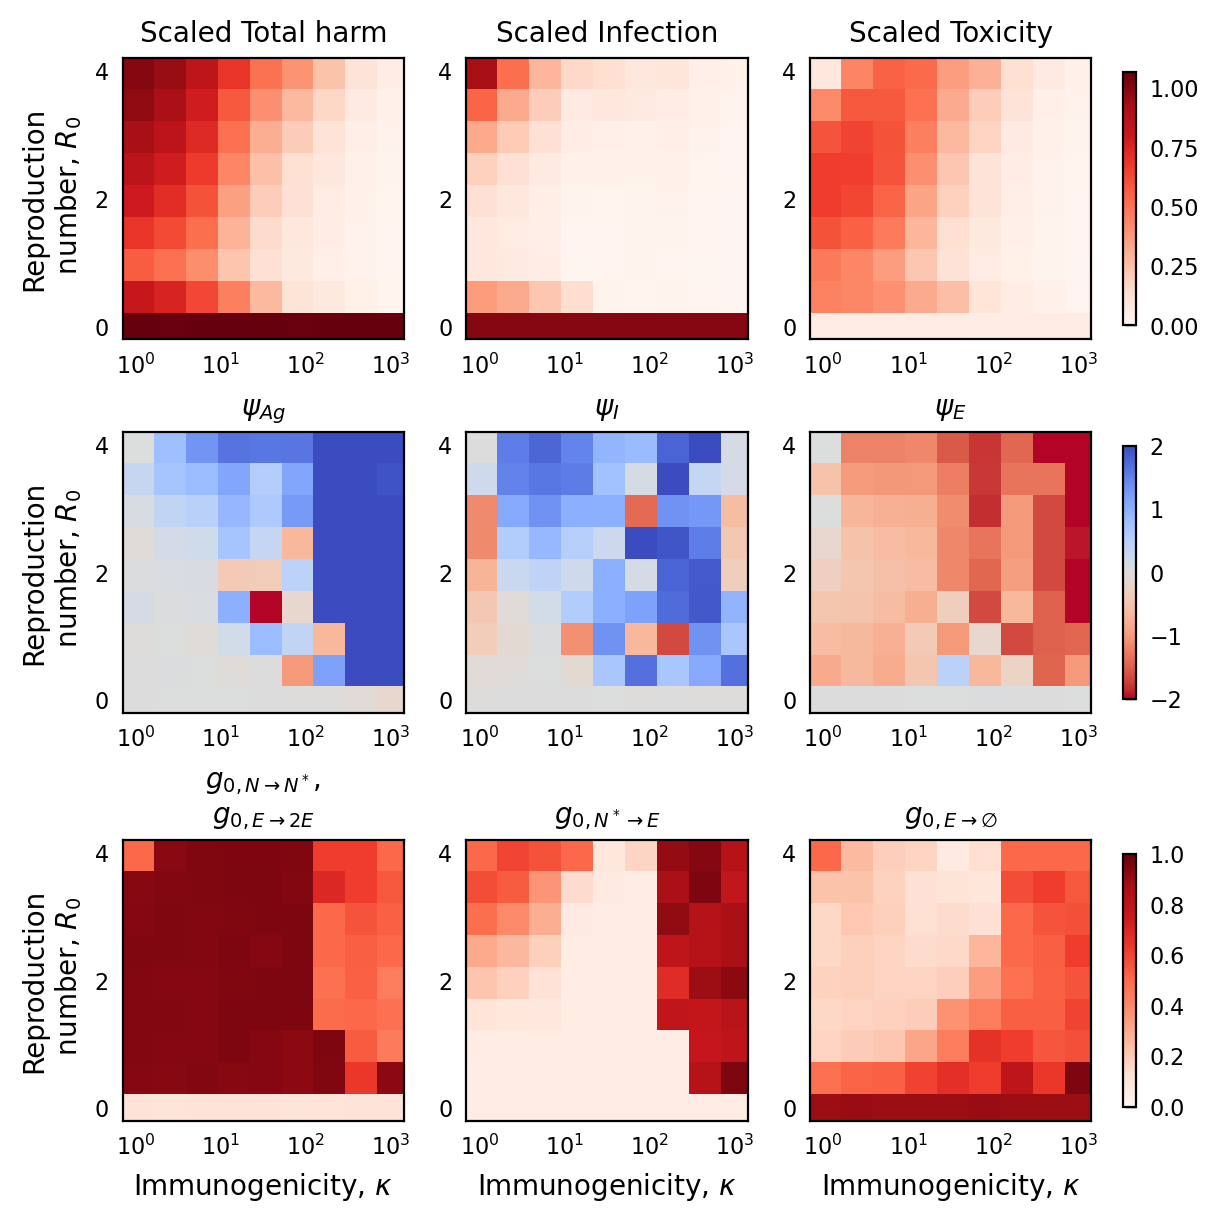

In [12]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 6), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 0)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    # ax.tricontour(cluster_input['S_0']/cluster_input[plots[0]], 
    #               1.0*cluster_input[plots[1]], 
    #              cluster_input['phase_cluster'], levels = phase_clusters, linewidths=2.0, colors=cluster_colors)

    # ax.tricontour(S_0/data[plots[0]], data[plots[1]], z, 
    #               linewidths=0.1, colors='k')
    
    # im = ax.tricontourf(S_0/data[plots[0]], data[plots[1]], z, 
    #                     cmap='Purples' if k <=2 else 'coolwarm_r',
    #              norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range if k < 6 else 1.0))

    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap=['Reds','coolwarm_r', 'Reds'][k // 3], edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0.0, vmax = np.amax(data[perf_vars[0]])) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range if k < 6 else 1.0))

    z_label = (['Scaled ' + perf_labels[0], 'Scaled ' + perf_labels[1], 'Scaled ' + perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    ax.set_title(z_label, fontsize = 10.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    if k % 3 == 2:
        cb = fig.colorbar(im, ax=axs[k // 3,:], location='right', shrink = 0.9, pad = 0.025)
        # cb.set_label(z_label, fontsize = 10)
        cb.ax.tick_params(labelsize=8)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_prot_strong_feedback_reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

The optimal response depends on the Immunogenicity of the pathogens encountered. The optimal design of the response to high Immunogenicity pathogens demonstrates the logic that the system should be tuned to respond to threats that it can easily detect.

In [13]:
# Add cluster information to data
cluster_sim_df = use_sim_data.merge(cluster_input[['idx','phase_cluster']], how = 'left', on = ['idx'])
#cluster_sim_df.loc[:,'phase_cluster'] = cluster_sim_df.apply(lambda row: int(np.mean(cluster_input.phase_cluster.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))])), axis = 1)

# Compute design performance in each cluster
avg_cluster_data = cluster_sim_df.groupby(opt_vars + ['phase_cluster'], as_index = False).mean()

In [14]:
check_merge = cluster_sim_df.loc[np.isnan(cluster_sim_df.phase_cluster.values)]
len(check_merge)

0

In [15]:
# Compute optimal performance as a function of allowed feedback strength
cluster_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 0.05)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'],as_index = False)
                                                  ))

# Compute optimal performance as a function of each individual single design 
# ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
#                           batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 0.05)
#                                                    for (_, g) in cluster_sim_df.groupby(vir_vars)
#                                                   ))

cluster_ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 0.05)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'], as_index = False)
                                                  ))

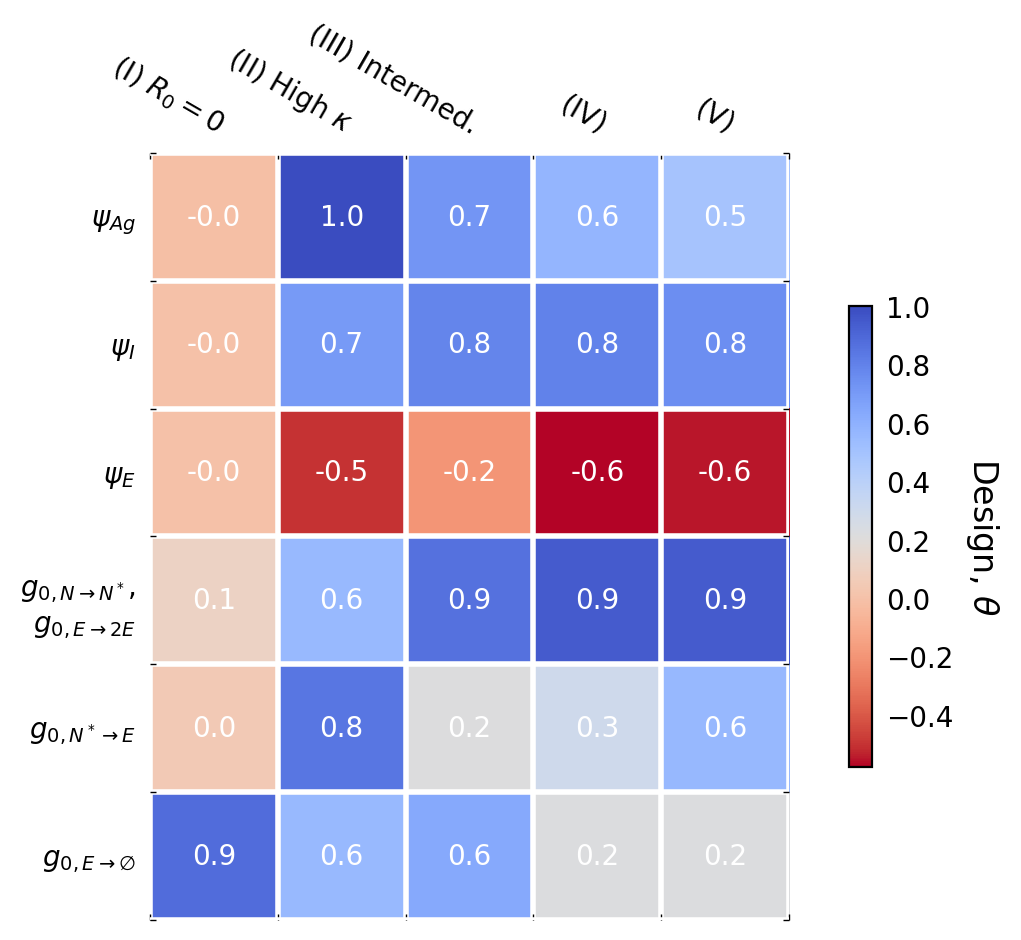

In [16]:
row_labels = opt_vars_labels
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0][opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).T

fig, ax = plt.subplots()
im = ax.imshow(opt_reg_data, cmap = 'coolwarm_r')

# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax, shrink = 0.6)
cbar.ax.set_ylabel(r"Design, $\theta$", rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(col_labels)), labels=col_labels,
              rotation=-30, ha="right", rotation_mode="anchor")
ax.set_yticks(np.arange(len(row_labels)), labels=row_labels)

# Let the horizontal axes labeling appear on top.
ax.tick_params(top=True, bottom=False,
               labeltop=True, labelbottom=False)

# Loop over data dimensions and create text annotations.
for i in np.arange(len(row_labels)):
    for j in np.arange(len(col_labels)):
        text = ax.text(j, i, np.round(opt_reg_data[i, j], 1),
                       ha="center", va="center", color="w")

# Turn spines off and create white grid.
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(opt_reg_data.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(opt_reg_data.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="major", bottom=False, left=False, top = False, right = False)
# #ax.set_title("Optimal feedback designs")
#ax.minorticks_off()

fig.tight_layout()
plt.show()

fig.savefig('_figs/figSI_'+comment+'-reg-cluster_opt-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=150)

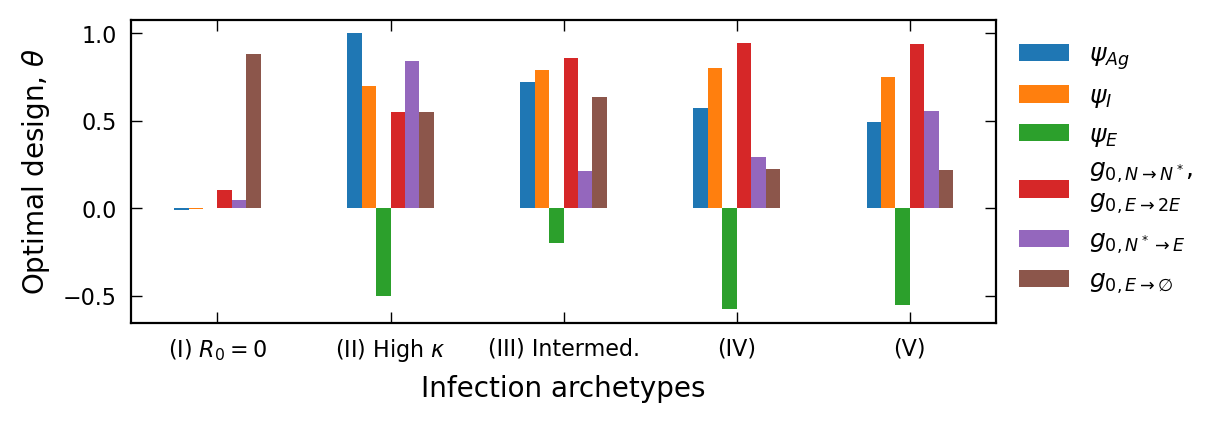

In [17]:
# Prepare data
row_labels = opt_vars_labels
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0][opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).tolist()

# Plot optimal designs
fig, axs = plt.subplots(1,1, figsize=(6, 2.0), sharex='row', sharey=False,layout='constrained')

df = pd.DataFrame(opt_reg_data, index=phase_cluster_labels, columns = opt_vars_labels)

df.plot.bar(ax=axs, color = cmap_colors)
axs.set_ylabel(r"Optimal design, $\theta$", fontsize = 10)
axs.legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)

axs.minorticks_off()
axs.tick_params(axis='both', which='major', labelsize=8)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=6)
axs.locator_params(axis='x', nbins=5)
axs.set_xlabel('Infection archetypes', fontsize = 10)
axs.set_xticklabels(col_labels, rotation='horizontal', size = 8)

fig.savefig('_figs/fig3_'+comment+'-reg-cluster_opt-reg_bars'+'.pdf', format="pdf", transparent=True, dpi=150)

In [18]:
# Install package to run Kneedle algorithm: https://pypi.org/project/kneed/
!pip install --upgrade kneed
from kneed import KneeLocator

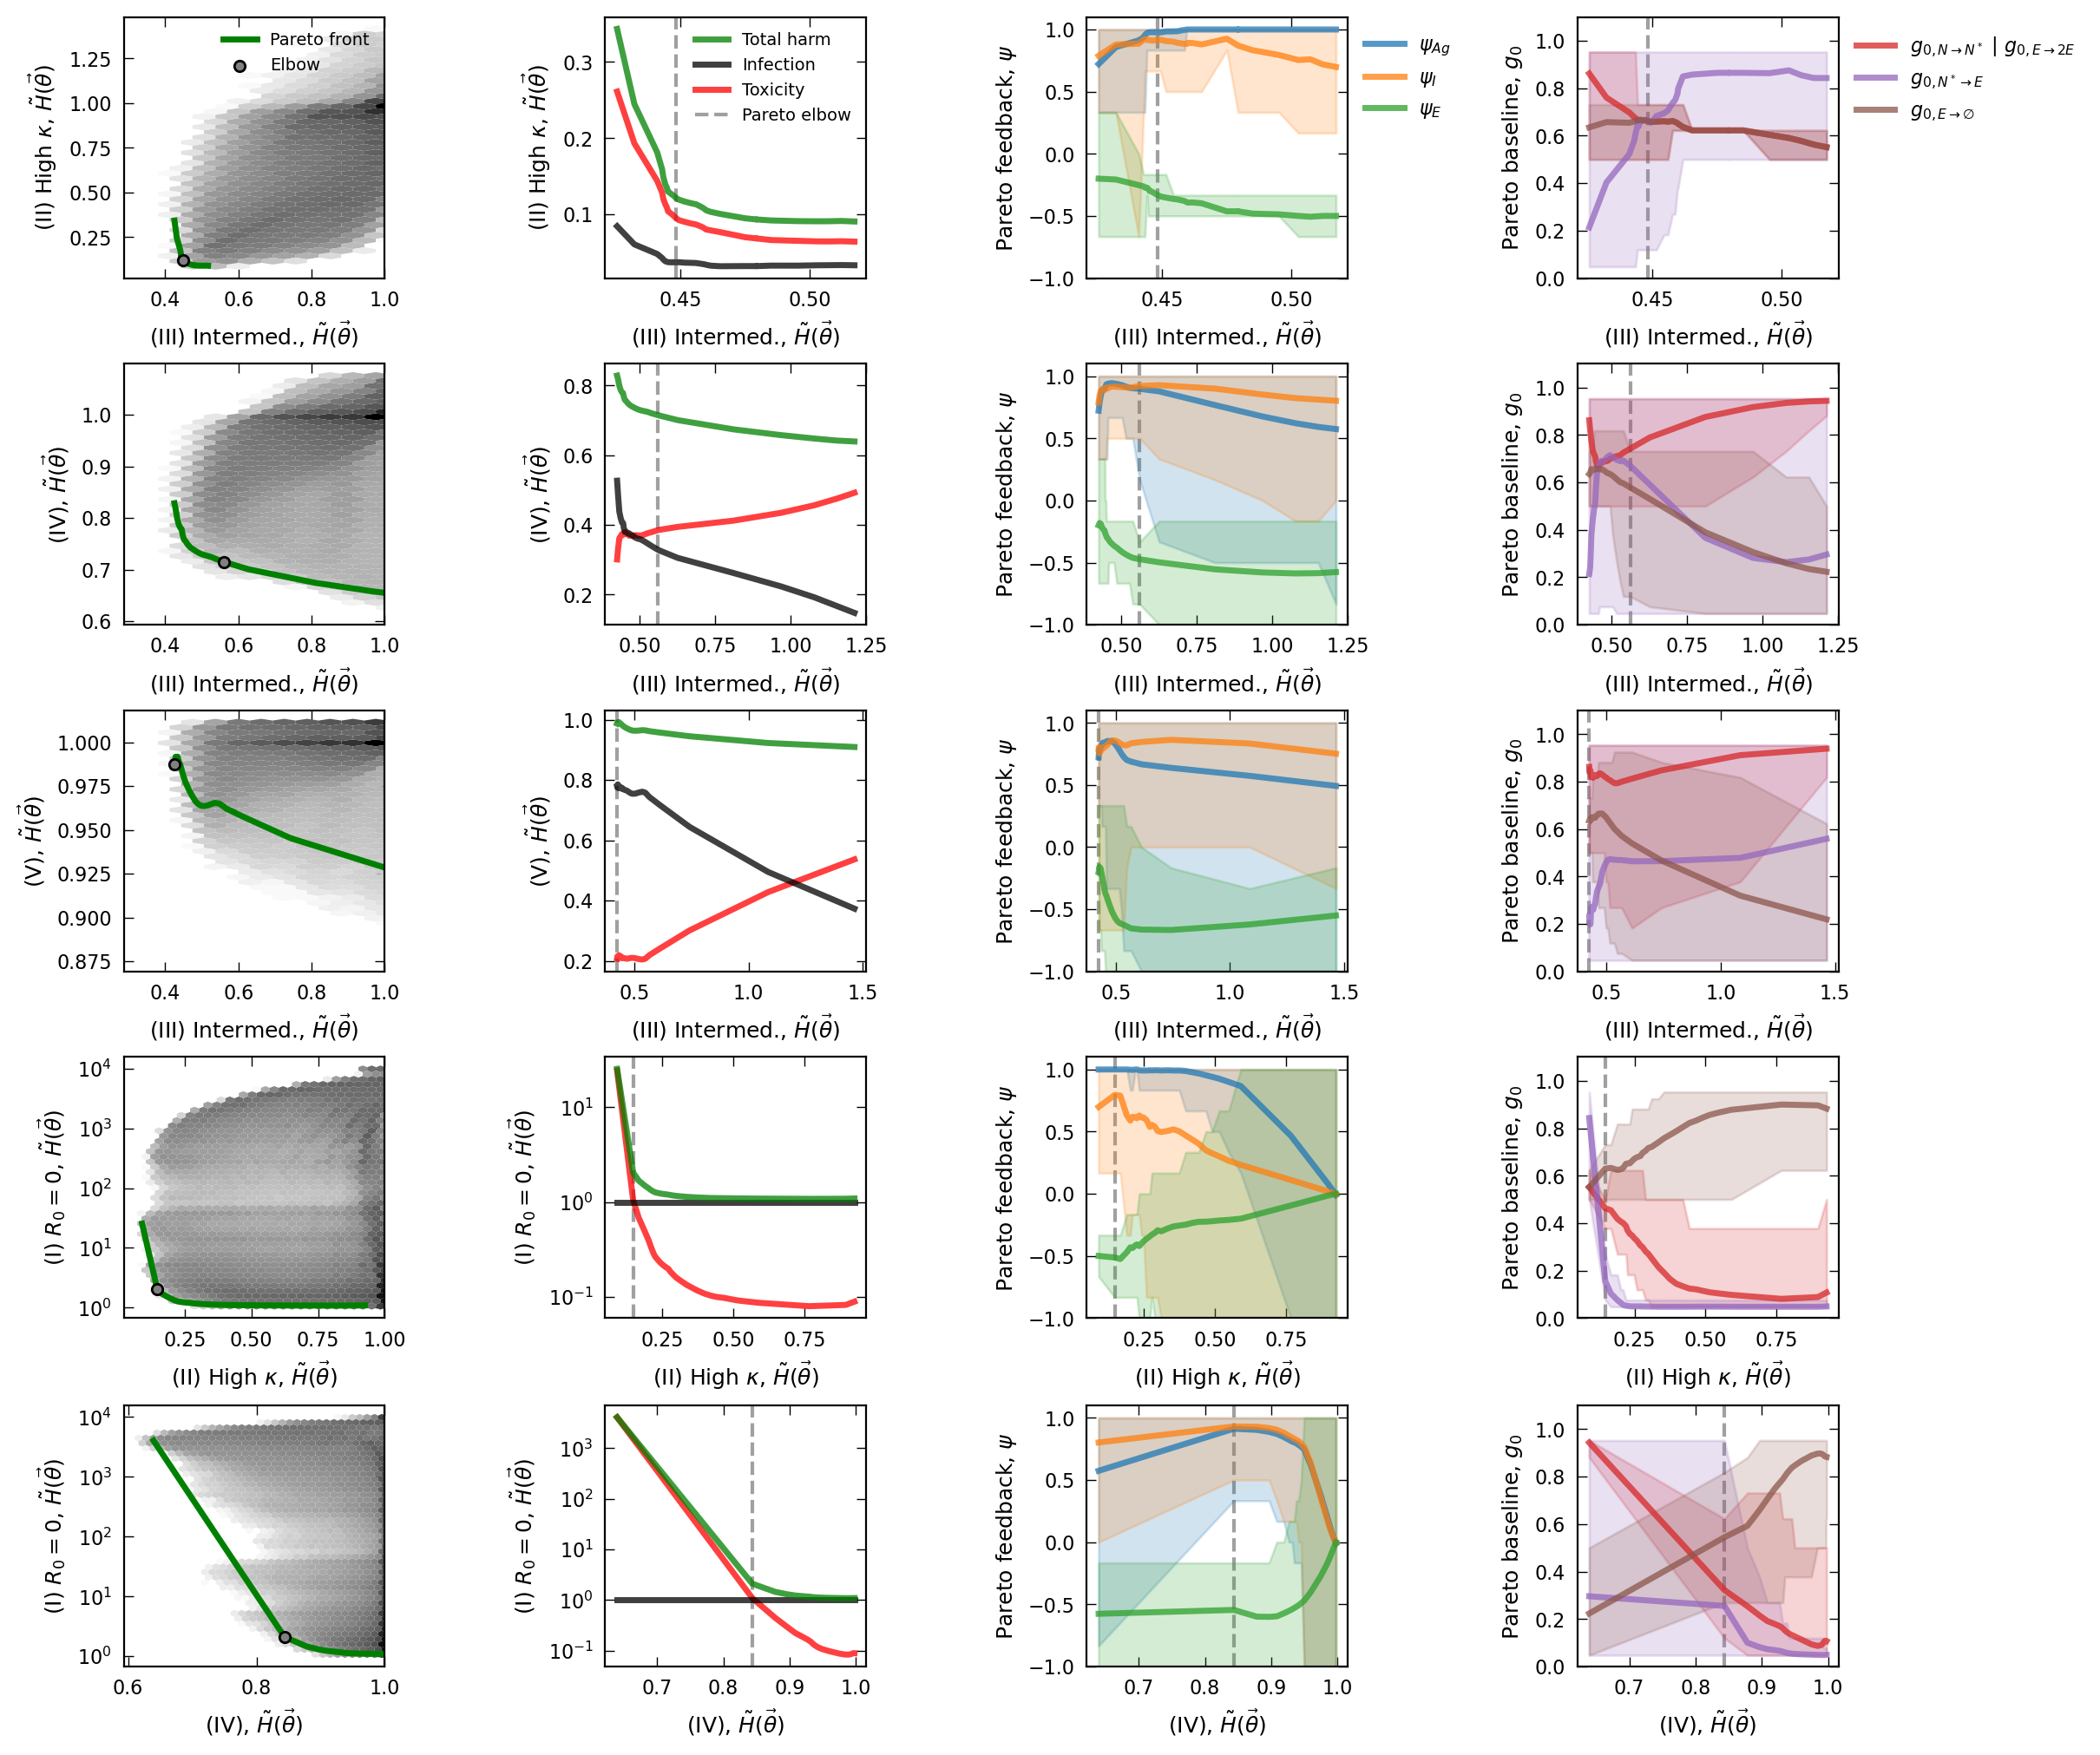

In [60]:
# Visualize pareto regulation
perf = 0
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

subsets = [[2,1], [2,3], [2,4], [1,0], [3,0]] #, [4,0]]
fig, axs = plt.subplots(len(subsets), 4, figsize=(12, len(subsets)*2), sharex=False, sharey=False,layout='constrained')

for k, [a, b] in enumerate(subsets):
    # (a) Effect of H_E ablation on Harm
    a_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == a)]
    b_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)]
    
    plot_data = a_group.loc[a_group.peff_scaled_total_harm > 0].merge(b_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))
    
    im = axs[k,0].hexbin(plot_data['peff_scaled_total_harm'].values, 
                         plot_data['peff_scaled_total_harm_comp'].values,
                         gridsize = 40, C = None, yscale='log' if k >= 3 else 'linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    lambdas = np.linspace(0,1, 31) 
    axs[k,0].set_xlim(None,1.0)

    pareto_designs = []
    max_pareto_designs, min_pareto_designs = [], []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = (1-l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        near_rows = data_sorted.loc[data_sorted.compromise <= 1.05*np.min(data_sorted.compromise)]
        opt_row = near_rows.mean() # data_sorted.head(1).mean()
        max_row = near_rows.max()
        min_row = near_rows.min()
        pareto_designs.append(opt_row.values)
        max_pareto_designs.append(max_row.values)
        min_pareto_designs.append(min_row.values)

    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
    max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
    min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())

    kn = KneeLocator(pareto_design_df.peff_scaled_total_harm, 
                     pareto_design_df.peff_scaled_total_harm_comp, curve='convex', direction='decreasing')
    equal_design = pareto_design_df.loc[np.abs(pareto_design_df.peff_scaled_total_harm - kn.knee).idxmin()]
    
    axs[k,0].plot(pareto_design_df['peff_scaled_total_harm'].values, 
                  pareto_design_df['peff_scaled_total_harm_comp'].values,
                  color='green', linewidth = 2.5, alpha = 1.0,
               label = "Pareto front")
    
    axs[k,0].scatter(equal_design['peff_scaled_total_harm'], 
                   equal_design['peff_scaled_total_harm_comp'],
                   label = r"Elbow",
           s = 20,
           color='grey', edgecolors = 'black', zorder = 2)
    
    for l, perf in enumerate(perf_vars[0:3]):
        axs[k,1].plot(pareto_design_df[perf_vars[0]].values,
                      pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                      color = perf_var_colors[l],
                    zorder = 3 - l,
                    label = perf_labels[l], 
                    **kwargs)
    
    for i, var in enumerate(opt_vars):
        if i < 3:
            axs[k,2].fill_between(pareto_design_df[perf_vars[0]].values, 
                                np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                                np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,2].plot(pareto_design_df[perf_vars[0]].values,
                          pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)
    
        if i >= 3:
            axs[k,3].fill_between(pareto_design_df[perf_vars[0]].values, 
                                np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                                np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,3].plot(pareto_design_df[perf_vars[0]].values,
                          pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)

    axs[k,1].axvline(x = equal_design.peff_scaled_total_harm, 
               color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0,
               label = r"Pareto elbow")
    axs[k,2].axvline(x = equal_design.peff_scaled_total_harm, color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)
    axs[k,3].axvline(x = equal_design.peff_scaled_total_harm, color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)

    axs[k,0].set_ylabel(phase_cluster_labels[b]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)
    axs[k,0].set_xlabel(phase_cluster_labels[a]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)
    
    axs[k,1].set_ylabel(phase_cluster_labels[b]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)
    axs[k,1].set_xlabel(phase_cluster_labels[a]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)

    axs[k,2].set_xlabel(phase_cluster_labels[a]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)
    axs[k,2].set_ylabel("Pareto feedback, "+ r"$\psi$", fontsize = 9)
    axs[k,2].set_ylim(-1.0, 1.1)
    axs[k,3].set_xlabel(phase_cluster_labels[a]+", "+r"$\tilde{H}(\vec\theta)$", fontsize = 9)
    axs[k,3].set_ylabel("Pareto baseline, "+ r"$g_0$", fontsize = 9)
    axs[k,3].set_ylim(0.0, 1.1)

axs[3,0].semilogy()
axs[4,0].semilogy()
# axs[5,0].semilogy()
axs[3,1].semilogy()
axs[4,1].semilogy()
axs[0,0].legend(loc='upper right',fontsize=7, framealpha=0, ncol = 1)
axs[0,1].legend(fontsize=7, framealpha=0, ncol = 1)
axs[0,2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=8)
axs[0,3].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=8)
#axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_compare_phases'+'.pdf', format="pdf", transparent=True, dpi=150) #, bbox_inches="tight")

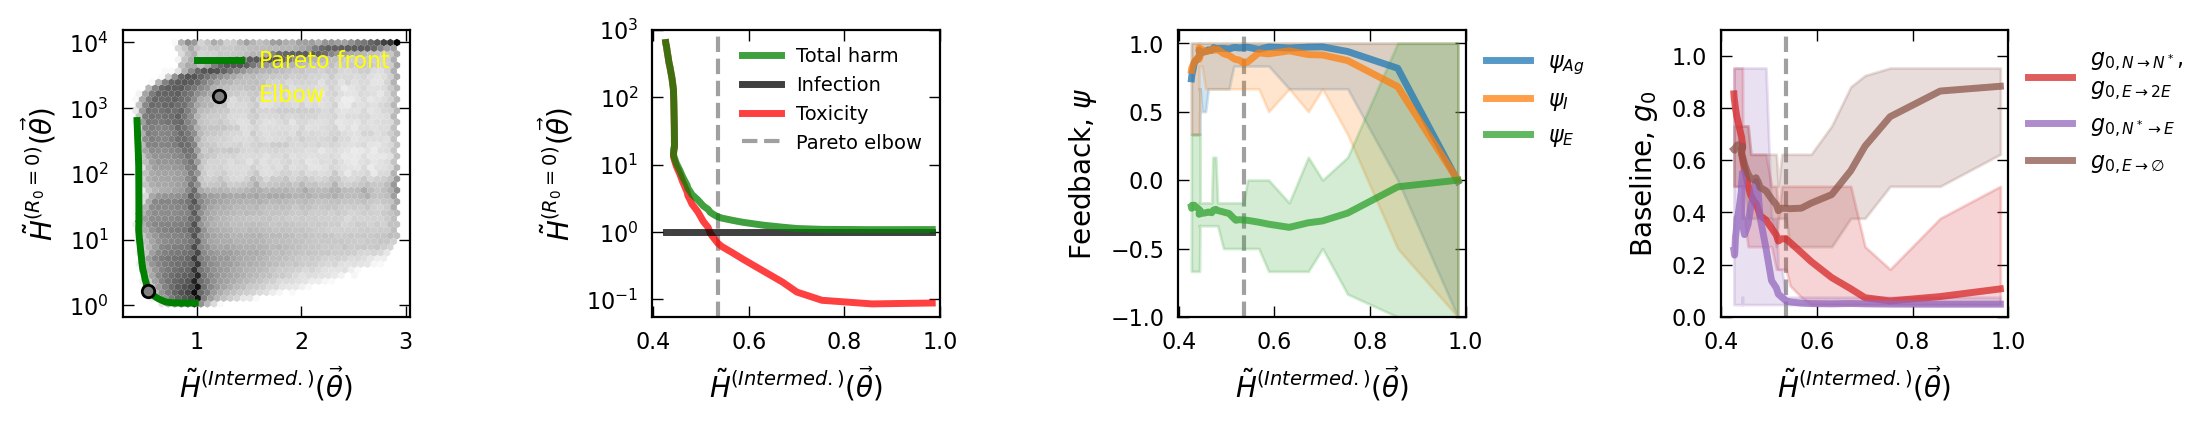

In [20]:
# Visualize pareto regulation
perf = 0
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(1, 4, figsize=(11, 2), sharex=False, sharey=False, layout='constrained')

lambdas = np.logspace(-6,0, 51)
ag_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 2)]
lowR0_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 0)]

plot_data = ag_group.loc[ag_group.peff_scaled_total_harm > 0].merge(lowR0_group[opt_vars + perf_vars + ['peff_total_harm'] + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

im = axs[0].hexbin(plot_data['peff_scaled_total_harm'].values, 
                     plot_data['peff_scaled_total_harm_comp'].values,
                     gridsize = 40, C = None,  yscale='log',
                     cmap='Grays', edgecolors = 'None',
                     norm = mpl.colors.LogNorm())

pareto_designs = []
max_pareto_designs, min_pareto_designs = [], []

# In
for l in lambdas:
    plot_data.loc[:,'compromise'] = (1-l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values
    plot_data.loc[:,'lambda'] = l
    data_sorted = plot_data.sort_values(by='compromise', ascending= True)
    near_rows = data_sorted.loc[data_sorted.compromise <= 1.05*np.min(data_sorted.compromise)]
    opt_row = near_rows.mean() # data_sorted.head(1).mean() #
    max_row = near_rows.max()
    min_row = near_rows.min()
    pareto_designs.append(opt_row.values)
    max_pareto_designs.append(max_row.values)
    min_pareto_designs.append(min_row.values)

pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())

kn = KneeLocator(pareto_design_df.loc[pareto_design_df['peff_scaled_total_harm_comp'] <= 10].peff_scaled_total_harm, 
                 pareto_design_df.loc[pareto_design_df['peff_scaled_total_harm_comp'] <= 10].peff_scaled_total_harm_comp, 
                 curve='convex', direction='decreasing')
equal_design = pareto_design_df.loc[np.abs(pareto_design_df.peff_scaled_total_harm - kn.knee).idxmin()]

#equal_design = pareto_design_df.loc[pareto_design_df['peff_toxicity_comp'] < pareto_design_df['peff_infection_comp']].iloc[0]

axs[0].plot(pareto_design_df['peff_scaled_total_harm'].values, 
              pareto_design_df['peff_scaled_total_harm_comp'].values,
              color='green', linewidth = 2.5, alpha = 1.0,
           label = "Pareto front")

axs[0].scatter(equal_design['peff_scaled_total_harm'], 
               equal_design['peff_scaled_total_harm_comp'],
               label = r"Elbow",
       s = 20,
       color='grey', edgecolors = 'black', zorder = 2)

for l, perf in enumerate(perf_vars[0:3]):
    axs[1].plot(pareto_design_df[perf_vars[0]].values,
                  pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                  color = perf_var_colors[l],
                zorder = 3 - l,
                label = perf_labels[l], 
                **kwargs)

for i, var in enumerate(opt_vars):
    if i < 3:
        axs[2].fill_between(pareto_design_df[perf_vars[0]].values, 
                            np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[2].plot(pareto_design_df[perf_vars[0]].values,
                      pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

    if i >= 3:
        axs[3].fill_between(pareto_design_df[perf_vars[0]].values, 
                            np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[3].plot(pareto_design_df[perf_vars[0]].values,
                      pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

axs[1].axvline(x = equal_design.peff_scaled_total_harm, 
               color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0,
               label = r"Pareto elbow")
axs[2].axvline(x = equal_design.peff_scaled_total_harm, color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)
axs[3].axvline(x = equal_design.peff_scaled_total_harm, color = 'grey', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)
axs[1].set_xlim(None, 1.0)
axs[1].semilogy()
# axs[1].set_yscale('symlog')

r'$\Delta \frac{H_I^{opt.}}{H^{E = 0}}$'

axs[0].set_ylabel(r"$\tilde{H}^{(R_0 = 0)}(\vec\theta)$", fontsize = 10)
axs[0].set_xlabel(r"$\tilde{H}^{(Intermed.)}(\vec\theta)$", fontsize = 10)

axs[1].set_ylabel(r"$\tilde{H}^{(R_0 = 0)}(\vec\theta)$", fontsize = 10)
axs[1].set_xlabel(r"$\tilde{H}^{(Intermed.)}(\vec\theta)$", fontsize = 10)

axs[2].set_xlabel(r"$\tilde{H}^{(Intermed.)}(\vec\theta)$", fontsize = 10)
axs[2].set_ylabel("Feedback, "+ r"$\psi$", fontsize = 10)
axs[2].set_ylim(-1.0, 1.1)
axs[2].set_xlim(None, 1.0)

axs[3].set_xlabel(r"$\tilde{H}^{(Intermed.)}(\vec\theta)$", fontsize = 10)
axs[3].set_ylabel("Baseline, "+ r"$g_0$", fontsize = 10)
axs[3].set_ylim(.0, 1.1)
axs[3].set_xlim(None, 1.0)

axs[0].legend(fontsize=8, loc='upper right', framealpha=0, labelcolor = 'yellow')
axs[1].legend(fontsize=7, framealpha=0)
axs[2].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)
axs[3].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)

# Store critical regulatory design
acute_pareto_reg = equal_design[opt_vars[0:3] + reg_bl].values #pareto_design_df[opt_vars[0:3] + reg_bl].values[np.argmin(np.abs(lambdas - 1/2))]

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('_figs/fig4_'+comment+'-pareto-prot_combined_phases'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

/tmp/ipykernel_38076/649688031.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_total_harm'].values/np.amax(np.abs(plot_data['peff_scaled_total_harm'].values))
/tmp/ipykernel_38076/649688031.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_tota

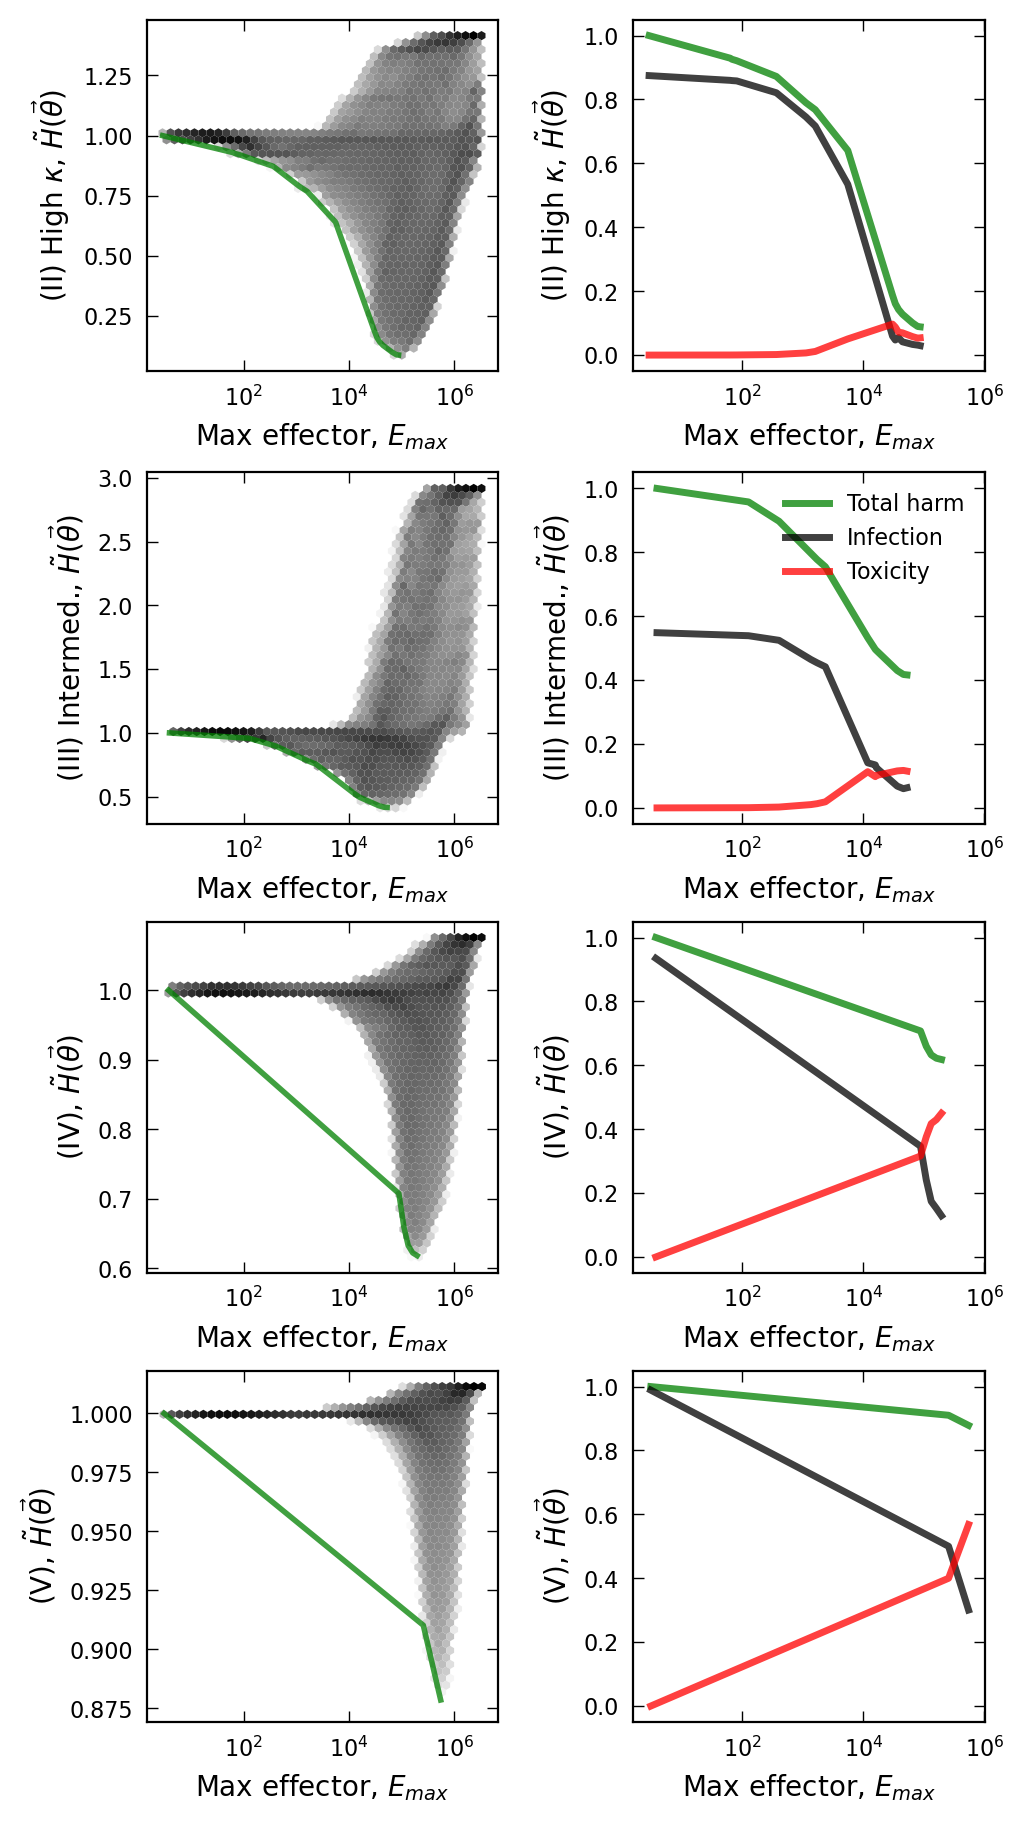

In [21]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(4, 2, figsize=(5, 4*2 + 1), sharex='col', sharey=False,layout='constrained')

lambdas = np.logspace(-6,0, 25)

for k, b in enumerate([1,2,3,4]):
    # (a) Effect of H_E ablation on Harm
    plot_data = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)*(avg_cluster_data.max_pE > 0)]

    # im = axs[k,0].scatter(plot_data['max_pE'].values,
    #                       plot_data['peff_scaled_total_harm'].values,
    #                       s = 2,
    #                       c = plot_data[opt_vars[2]], cmap='coolwarm_r',
    #                       edgecolors = 'None')

    im = axs[k,0].hexbin(plot_data['max_pE'].values,
                         plot_data['peff_scaled_total_harm'].values,
                         gridsize = 40, C = None,  
                         xscale='log',
                         yscale='linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    # axs[2,0].set_yscale('symlog')
    # axs[k,0].semilogx()
    # axs[k,0].set_ylim(None,0.5)

    pareto_designs = []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_total_harm'].values/np.amax(np.abs(plot_data['peff_scaled_total_harm'].values))
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        max_row = data_sorted.head(3).mean()
        #pareto_index = np.argmax((1 - l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values)

        pareto_designs.append(max_row) # plot_data.loc[pareto_index]

    pareto_design_df = pd.concat(pareto_designs)

    axs[k,0].plot(pareto_design_df['max_pE'].values, 
                  pareto_design_df['peff_scaled_total_harm'].values,
              color='green', linewidth = 2.0, alpha = 0.75,
             label = "Pareto" if k == 0 else "")

    for l, perf in enumerate(perf_vars[0:3]):
        axs[k,1].plot(pareto_design_df['max_pE'].values,
                      pareto_design_df[perf].values,
                      color = perf_var_colors[l],
                      label = perf_labels[l],
                      **kwargs)
        
        # axs[k,1].scatter(pareto_design_df['max_pE'].values,
        #                  pareto_design_df[perf].values,
        #                  color = perf_var_colors[l],
        #                  s = 20,
        #                  label = perf_labels[l])

    axs[k,0].set_ylabel(phase_cluster_labels[b]+r", $\tilde{H}(\vec\theta)$", fontsize = 10)
    axs[k,0].set_xlabel(r'Max effector, $E_{max}$', fontsize = 10)
    
    axs[k,1].set_xlabel(r'Max effector, $E_{max}$', fontsize = 10)
    axs[k,1].set_ylabel(phase_cluster_labels[b]+r", $\tilde{H}(\vec\theta)$", fontsize = 10)
    axs[k,1].semilogx()

axs[1,1].legend(fontsize=8, framealpha=0, ncol = 1)

for ax in axs.flat:
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

# fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-clusters_prot_effector'+'.pdf', format="pdf", transparent=True, dpi=300)

In [22]:
from optimize_nets import *

runs = 10
d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
ps = acute_pareto_reg

psis = np.array([[ps[0], ps[1], ps[2], ps[3], # Na
                 ps[0], ps[1], ps[2], ps[4], # NE
                 -0*ps[0], -0*ps[1], -0*ps[2], -L0_max**4 -0*ps[4], # EM
                 -ps[0], -ps[1], -ps[2], ps[5]]])  # Edie

sample = cluster_input[['d_I', 'K_I', 'b_I', 'K_H', 'N_0', 'I_0']].values


# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample, 
    comment="pareto_reg_sim", runs = runs, infection_model = 'acute', 
    default_reg = psis,
    num_cpu = num_cpu)

d_file = d + '/sim_batch_-1-10-acute-pareto_reg_sim.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
crit_reg_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]).merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

crit_reg_data.loc[:, 'R_0'] = crit_reg_data['S_0']*crit_reg_data['b_I']/crit_reg_data['d_I'] - 1
crit_reg_data.loc[:,opt_vars[0:3]] = np.round(crit_reg_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
crit_reg_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-crit_reg_data[reg_bl].values)), 3)
crit_reg_data.loc[:,"harm_pI_noprotection"] = crit_reg_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

crit_reg_data.loc[:,"peff_infection"] = crit_reg_data['harm_pI']/S_0
crit_reg_data.loc[:,"peff_toxicity"] = crit_reg_data['harm_pS']/S_0
crit_reg_data.loc[:,"peff_total_harm"] = crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity']
crit_reg_data.loc[:,"peff_scaled_total_harm"] = (crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity'])/crit_reg_data["harm_pI_noprotection"]

crit_eff_dyn_design = crit_reg_data.groupby(plots, as_index = False, sort = False).mean()
#crit_eff_dyn_design = cluster_sim_df.loc[np.sum(np.abs(cluster_sim_df[opt_vars[0:3] + reg_bl].values - acute_pareto_reg), axis = 1) == 0]
crit_eff_dyn_design.loc[:,"del_peff_scaled_total_harm"] = crit_eff_dyn_design.peff_scaled_total_harm/cluster_input.peff_scaled_total_harm.values
crit_eff_dyn_design.loc[:,"del_peff_infection_scaled"] = (crit_eff_dyn_design.peff_infection/cluster_input.peff_infection.values)
crit_eff_dyn_design.loc[:,"del_peff_toxicity_scaled"] = (crit_eff_dyn_design.peff_toxicity/cluster_input.peff_toxicity.values) #/crit_eff_dyn_design.harm_pI_noprotection

Running 810 simulations in batch #-1
Saved sim_batch_-1-10-acute-pareto_reg_sim.pkl
0.005989027155770196 hrs


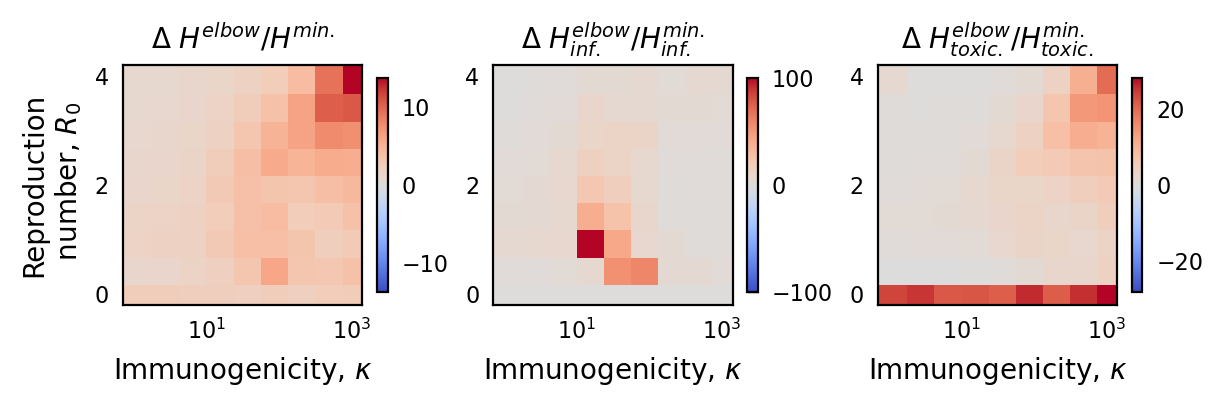

In [23]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(1, 3, 
                          figsize=(6, 2), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = ['del_peff_scaled_total_harm', 'del_peff_infection_scaled', 'del_peff_toxicity_scaled'] # 'harm_pI_noprotection'
data = crit_eff_dyn_design

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))
    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='coolwarm', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    z_label = ([r'$H^{elbow}/H^{min.}$',
                r'$H_{inf.}^{elbow}/H_{inf.}^{min.}$',
                r'$H_{toxic.}^{elbow}/H_{toxic.}^{min.}$'])[k]
    ax.set_title(r"$\Delta$ "+z_label, fontsize = 10.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    cb = fig.colorbar(im, ax=ax, location='right', shrink = 0.6, pad = 0.025)
    # cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_prot_delta_crit_reg_hmap'+'.pdf', dpi=300) #, bbox_inches="tight")

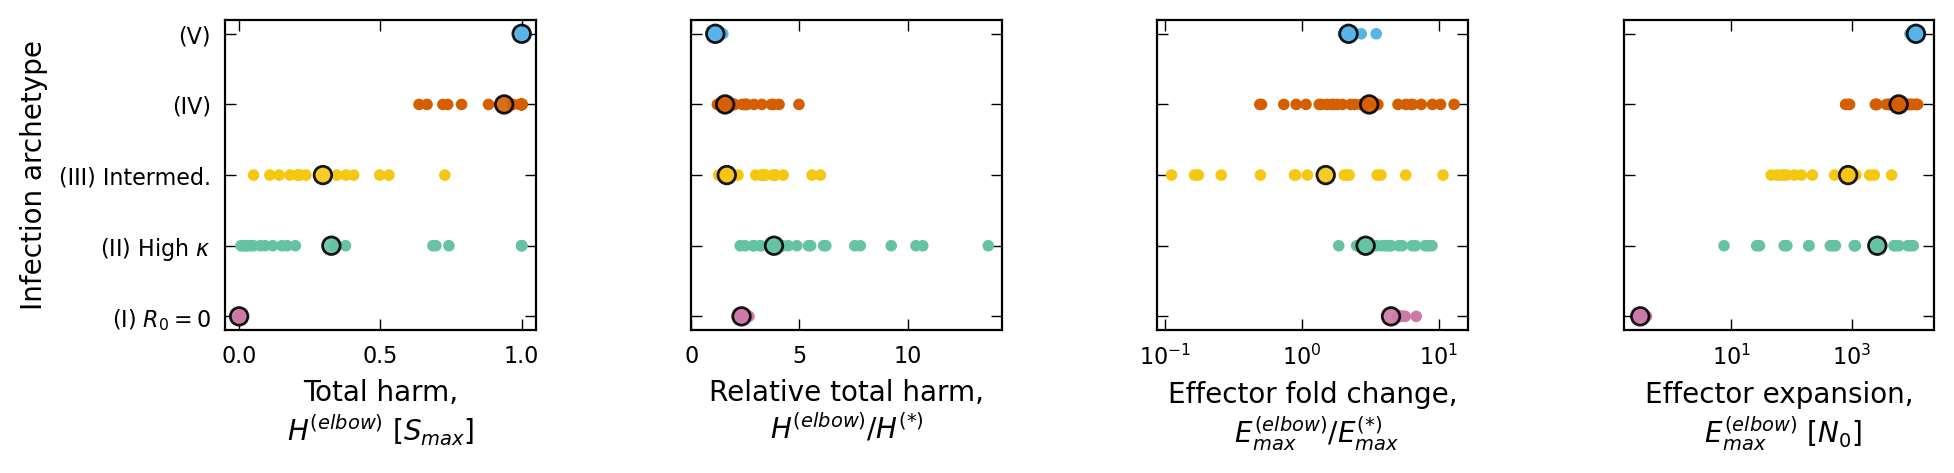

In [24]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2.25), sharey = True, constrained_layout=True)
plot_data = crit_eff_dyn_design.groupby(['phase_cluster'], as_index = False).mean() # avg_cluster_data.loc[np.sum(np.abs(avg_cluster_data[opt_vars[0:3] + reg_bl].values - acute_pareto_reg), axis = 1) == 0]

axs[0].scatter(plot_data.peff_total_harm.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[0].scatter(crit_eff_dyn_design.peff_total_harm, 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[0].set_xlabel('Total harm,\n'+r'$H^{(elbow)}$ [$S_{max}$]', fontsize = 10)

axs[1].scatter((plot_data.peff_total_harm.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].peff_total_harm.values), #/plot_data.harm_pI_noprotection.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[1].scatter(crit_eff_dyn_design.del_peff_scaled_total_harm, crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[1].set_xlabel('Relative total harm,\n'+r'$H^{(elbow)}/H^{(*)}$', fontsize = 10)
axs[1].set_xlim(0.0, None)

# axs[1].set_xlim(0.0, None)

axs[2].scatter((plot_data.max_pE.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].max_pE.values),
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[2].scatter((crit_eff_dyn_design.max_pE.values/cluster_input.max_pE.values), 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[2].set_xlabel('Effector fold change,\n $E_{max}^{(elbow)}/E_{max}^{(*)}$', fontsize = 10)
axs[2].semilogx()

axs[3].scatter(plot_data.max_pE.values/N_0,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[3].scatter(crit_eff_dyn_design.max_pE.values/N_0, 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[3].set_xlabel('Effector expansion,\n $E_{max}^{(elbow)}$ [$N_0$]', fontsize = 10)
axs[3].semilogx()
axs[0].set_ylabel('Infection archetype', fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_yticks(phase_clusters, phase_cluster_labels, rotation = 0)
    ax.xaxis.set_tick_params(labeltop=False)
    #ax.locator_params(axis='x', nbins=4)

fig.savefig('_figs/fig4_'+comment+'-reg-cluster_prot_delta_crit_reg_scatter'+'.pdf', format="pdf", transparent=True, dpi=300)

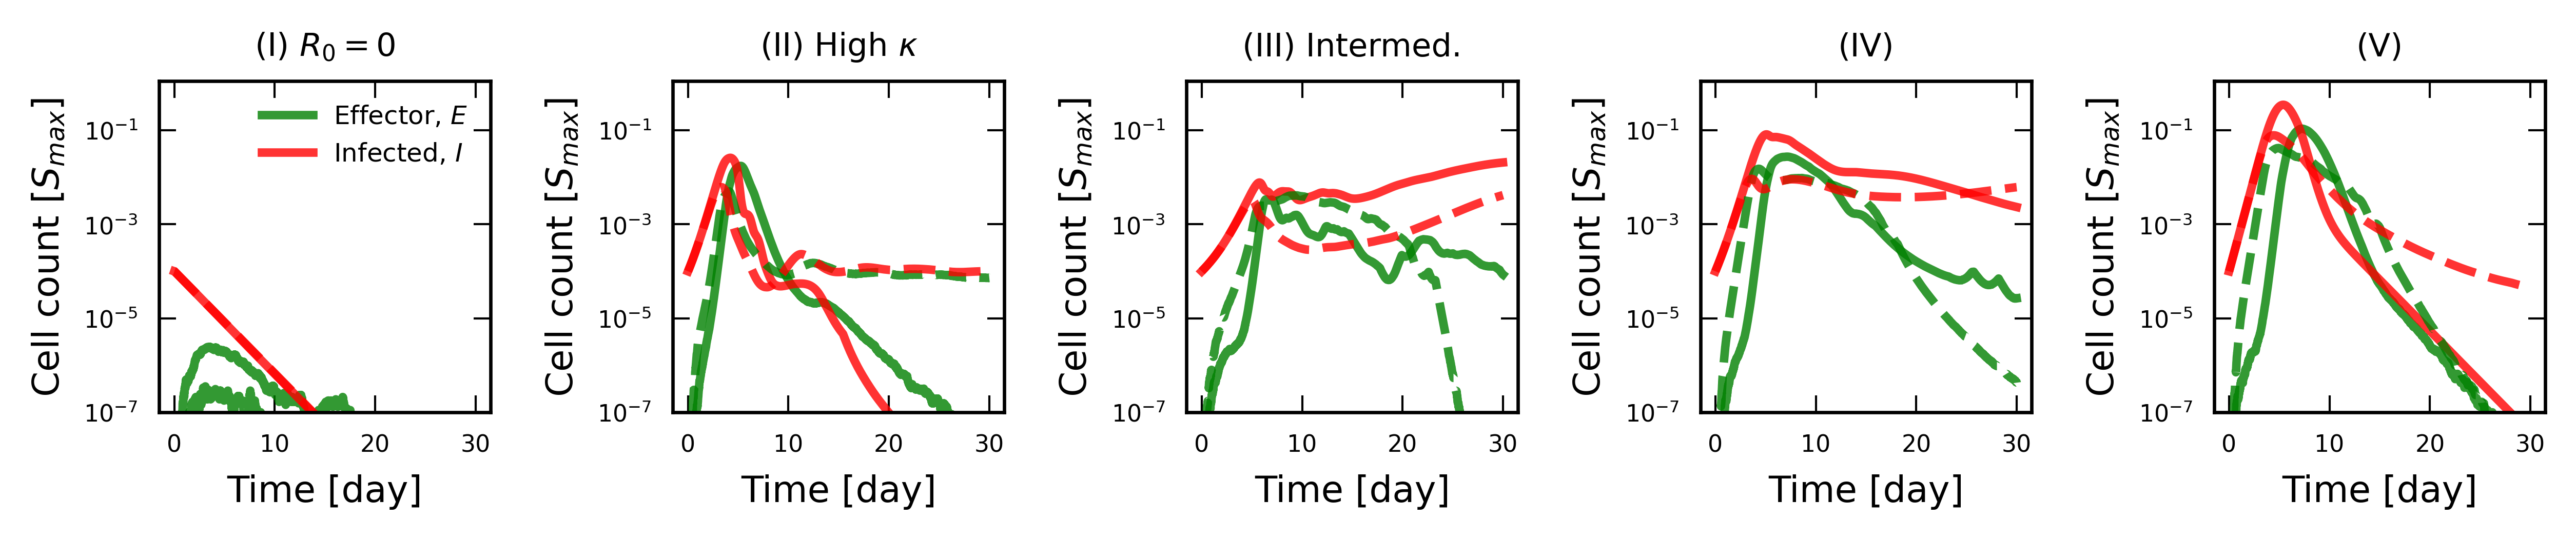

In [25]:
# Plot select infection responses
fig, axs = plt.subplots(1,n_clusters, dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*n_clusters, 2))
repeat = 1

# Loop and do 
for k, c in enumerate(phase_clusters):

    # Select infection
    select_cluster_data = cluster_input.loc[cluster_input.phase_cluster == c]
    infection_count = len(select_cluster_data)
    #v = select_cluster_data.loc[select_cluster_data[perf_vars[0]] >= select_cluster_data[perf_vars[0]].median(), vir_vars].iloc[0].values.ravel()
    opt_dyn, pareto_dyn = 0, 0

    for v in select_cluster_data[vir_vars].values:
        # Response optimized for single infection class
        p = cluster_grid_opt.loc[(cluster_grid_opt.perf_index == 0)*(cluster_grid_opt.phase_cluster == c), opt_vars[0:3] + reg_bl].values.ravel()
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        opt_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

        # Response optimized for moderate Immunogenicity and avoiding self
        p = acute_pareto_reg
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        pareto_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

    opt_S, opt_I, opt_E = opt_dyn[:,0]/infection_count, opt_dyn[:,1]/infection_count, opt_dyn[:,4]/infection_count
    pareto_S, pareto_I, pareto_E = pareto_dyn[:,0]/infection_count, pareto_dyn[:,1]/infection_count, pareto_dyn[:,4]/infection_count

    # Plot cell dynamics
    axs[k].plot(ts, pareto_E/S_0, linewidth=2.0, color = 'green', alpha = 0.8, label = "Effector, $E$")
    axs[k].plot(ts, pareto_I/S_0, linewidth=2.0, color = 'red', alpha = 0.8, label = "Infected, $I$")
    axs[k].plot(ts, opt_E/S_0, linewidth=2.0, color = 'green', alpha = 0.8, linestyle = '--')
    axs[k].plot(ts, opt_I/S_0, linewidth=2.0, color = 'red', alpha = 0.8, linestyle = '--')
    
    axs[k].set_title(phase_cluster_labels[k], fontsize = 7.5)

axs[0].legend(loc = 'upper right', fontsize=6, framealpha=0, ncol = 1)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.set_ylabel(r'Cell count [$S_{max}$]', fontsize = 8.5)
    ax.set_xlabel(r"Time [day]", fontsize = 8.5)
    ax.semilogy()
    ax.set_ylim(1/S_0, None)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.25)

plt.savefig('_figs/fig5_'+comment+'-opt-v-pareto-design-effect-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

##### Relationship between feedback strength and performance

In [26]:
# Compute optimal performance as a function of allowed feedback strength
cluster_feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 0.05)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster', 'feedback'],as_index = False)
                                                  ))

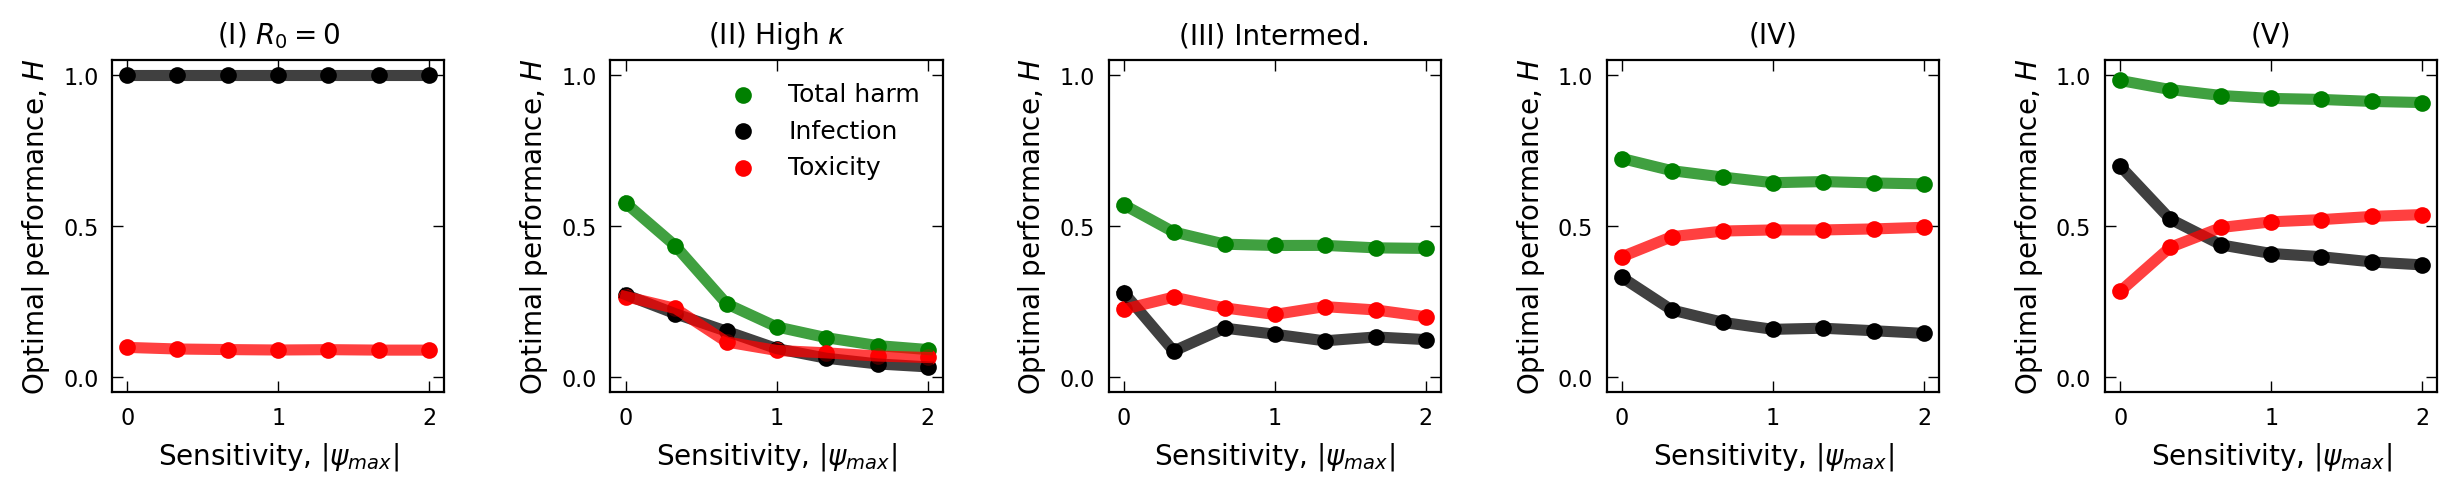

In [27]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, perf in enumerate(perf_vars[0:3]):
        axs.flat[k].plot(g['feedback'].values,
             g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
             color = perf_var_colors[i],
                            **kwargs)
    
        axs.flat[k].scatter(g['feedback'].values,
         g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
         color = perf_var_colors[i], 
         label = perf_labels[i])

    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)

for ax in axs.flat: 
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel(r"Optimal performance, $H$", fontsize = 10)
    ax.set_xlabel(r"Sensitivity, $|\psi_{max}|$", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_feedback'+'.pdf', format="pdf", transparent=True, dpi=300)

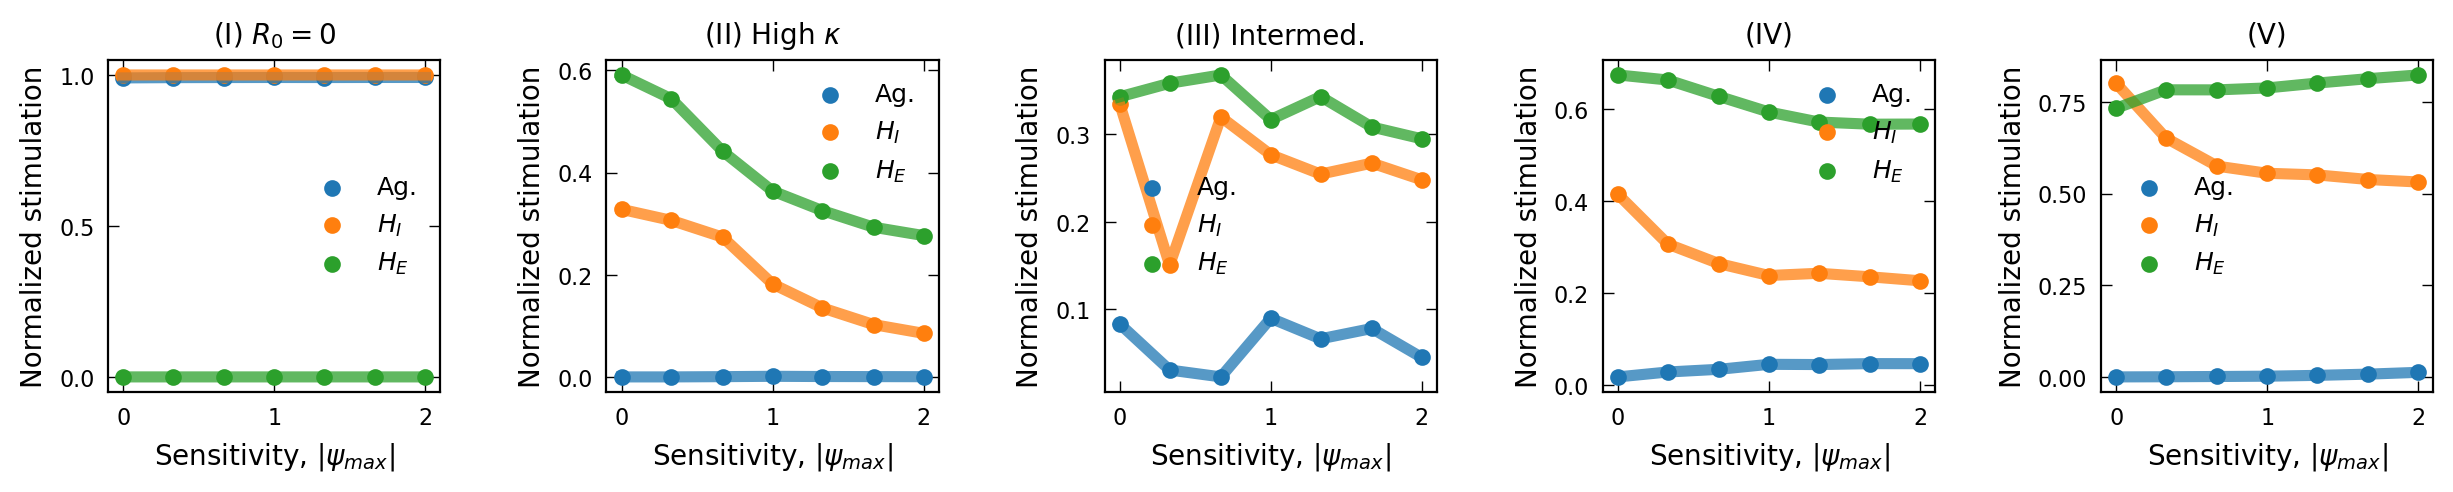

In [28]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, stim in enumerate(stim_vars):
        normalize = np.amax(avg_cluster_data.loc[(avg_cluster_data.phase_cluster == k), stim])
        axs[k].plot(g['feedback'].values,
             g[stim].values/normalize,
             color = cmap_colors[i],
                            **kwargs)
    
        axs[k].scatter(g['feedback'].values,
         g[stim].values/normalize,
         color = cmap_colors[i], 
         label = ['Ag.', r'$H_I$', r'$H_E$'][i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Normalized stimulation", fontsize = 10)
    ax.set_xlabel("Sensitivity, $|\psi_{max}|$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_feedback'+'.pdf', format="pdf", transparent=True, dpi=300)

Paradoxically, for a response to be protective, it drives down the infection feedback signals.

##### Relationship between design and performance

In [29]:
def choose_continous_color(x):
    if x == 0:
        out = plt.cm.Greys(x)
    elif x > 0:
        out = plt.cm.Blues(x)
    elif x < 0:
        out = plt.cm.Reds(np.abs(x))

    return out

In [30]:
# # Make trade-off figure
# chosen_perf = ['peff_total_harm', perf_vars[3]]
# fig, axs = plt.subplots(len(plots)*len(chosen_perf),len(opt_vars), 
#                         figsize=(len(plots)*len(chosen_perf)*2, len(opt_vars)), 
#                         sharex='row', sharey='row',layout='constrained')
# perf = 0

# kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

# for k, theta in enumerate(opt_vars):
#     data = cluster_sim_df.groupby(plots + [theta], as_index = False).mean()

#     # (a) Effect of single parameter ablation on Infection
#     for i, v in enumerate(plots):
#         use_data = data.groupby([v, theta], as_index = False).mean()
#         for l, perf in enumerate(chosen_perf):
#             axs[i*len(chosen_perf) + l,k].scatter(use_data[v].values,
#                                              use_data[perf].values,
#                                                   s = 5,
#                                                   color = [choose_continous_color(x) for x in use_data[theta].values],
#                                                   edgecolors = [choose_continous_color(x) for x in use_data[theta].values],#plt.cm.Reds(use_data[theta].values),
#                                              linewidth = 0.5)
#             if l == 1:
#                 axs[i*len(chosen_perf) + l,k].semilogy()

#             if i == 0:
#                 axs[i*len(chosen_perf) + l,k].semilogx()

#             axs[i*len(chosen_perf) + l,k].set_xlabel([r'$K_I$', r'$R_0$'][i], fontsize = 10)
#             axs[i*len(chosen_perf) + l,k].set_ylabel([perf_labels[0], perf_labels[-1]][l], fontsize = 10)

#     axs[0,k].set_title(opt_vars_labels[k], fontsize = 10.0)
    
# #axs.flat[1].legend(fontsize=8, framealpha=0, ncol = 1)
    
# for j, ax in enumerate(axs.flat):
#     ax.minorticks_off()
#     #ax.set_ylim(-0.05, None)
#     ax.set_box_aspect(1)
#     ax.tick_params(axis='both', which='major', labelsize=8)
#     #ax.locator_params(axis='y', nbins=4)
#     # ax.semilogy()
#     ax.xaxis.set_tick_params(labelbottom=True)
#     ax.yaxis.set_tick_params(labelleft=True)
#     # if j // 3 == 0:
#     #     ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# plt.savefig('_figs/figSI_'+comment+'-perf_mean_design_effect'+'.pdf', format="pdf", transparent=True, dpi=300)

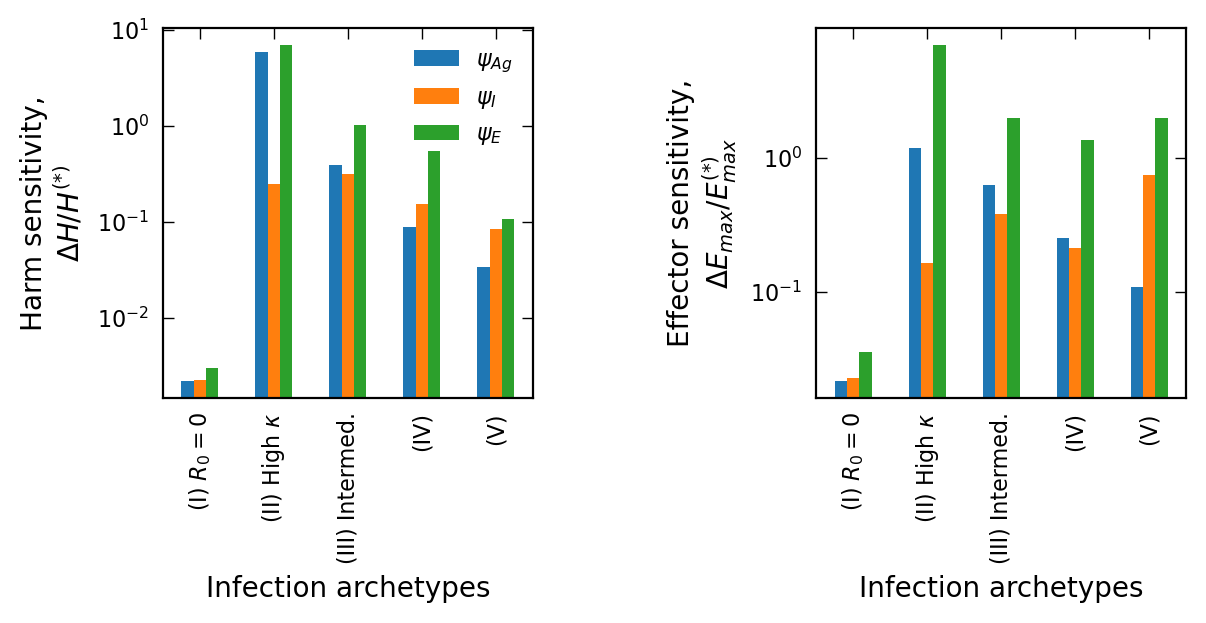

In [31]:
fig, axs = plt.subplots(1,2, figsize=(6.5, 3), sharex='row', sharey=False,layout='constrained')

# Prepare data
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index < 3)]
opts = cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0]

# Plot harm
range_data = data.groupby(['phase_cluster', 'ablate_index']).max() - data.groupby(['phase_cluster', 'ablate_index']).min()
groups = [(range_data.loc[i].peff_total_harm.values/opts.loc[opts.phase_cluster == i].peff_total_harm.item()).tolist() for i in phase_clusters]
group_labels = phase_cluster_labels

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[0:3])

df.plot.bar(ax=axs[0], color = cmap_colors)
axs[0].set_ylabel("Harm sensitivity,\n"+r'$\Delta H/H^{(*)}$', fontsize = 10)
axs[0].legend(fontsize=8)

# Plot effectors
groups = [(range_data.loc[i].max_pE.values/opts.loc[opts.phase_cluster == i].max_pE.item()).tolist() for i in phase_clusters]

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[0:3])

df.plot.bar(ax=axs[1], color = cmap_colors, legend = False)
axs[1].set_ylabel("Effector sensitivity,\n"+r'$\Delta E_{max}/E_{max}^{(*)}$', fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.semilogy()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.minorticks_off()
    #axs.locator_params(axis='y', nbins=4)
    #ax.locator_params(axis='x', nbins=4)
    ax.set_xlabel('Infection archetypes', fontsize = 10)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_feedback'+'.pdf', format="pdf", transparent=True, dpi=300)

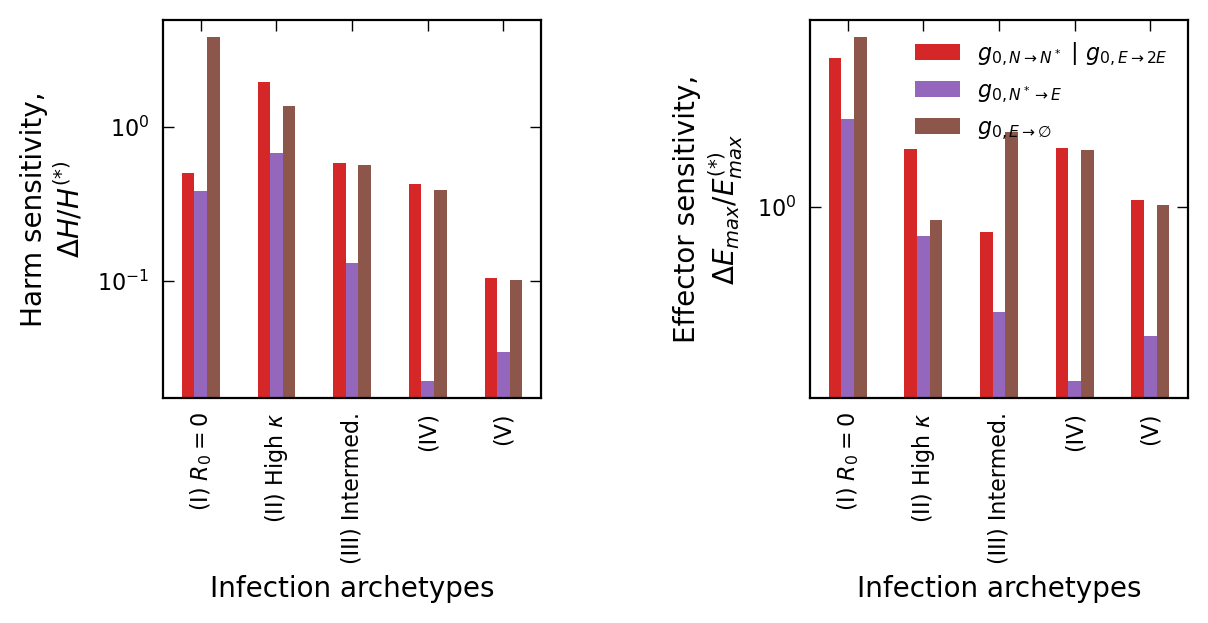

In [32]:
fig, axs = plt.subplots(1,2, figsize=(6.5, 3), sharex='row', sharey=False,layout='constrained')

# Prepare data
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index >= 3)]
opts = cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0]

# Plot harm
range_data = data.groupby(['phase_cluster', 'ablate_index']).max() - data.groupby(['phase_cluster', 'ablate_index']).min()
groups = [(range_data.loc[i].peff_total_harm.values/opts.loc[opts.phase_cluster == i].peff_total_harm.item()).tolist() for i in phase_clusters]
group_labels = phase_cluster_labels

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[3:])

df.plot.bar(ax=axs[0], color = cmap_colors[3:], legend = False)
axs[0].set_ylabel("Harm sensitivity,\n"+r'$\Delta H/H^{(*)}$', fontsize = 10)

# Plot effectors
groups = [(range_data.loc[i].max_pE.values/opts.loc[opts.phase_cluster == i].max_pE.item()).tolist() for i in phase_clusters]

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[3:])

df.plot.bar(ax=axs[1], color = cmap_colors[3:])
axs[1].legend(fontsize=8)
axs[1].set_ylabel("Effector sensitivity,\n"+r'$\Delta E_{max}/E_{max}^{(*)}$', fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.semilogy()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.minorticks_off()
    #axs.locator_params(axis='y', nbins=4)
    #ax.locator_params(axis='x', nbins=4)
    ax.set_xlabel('Infection archetypes', fontsize = 10)
    
plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_baseline'+'.pdf', format="pdf", transparent=True, dpi=300)

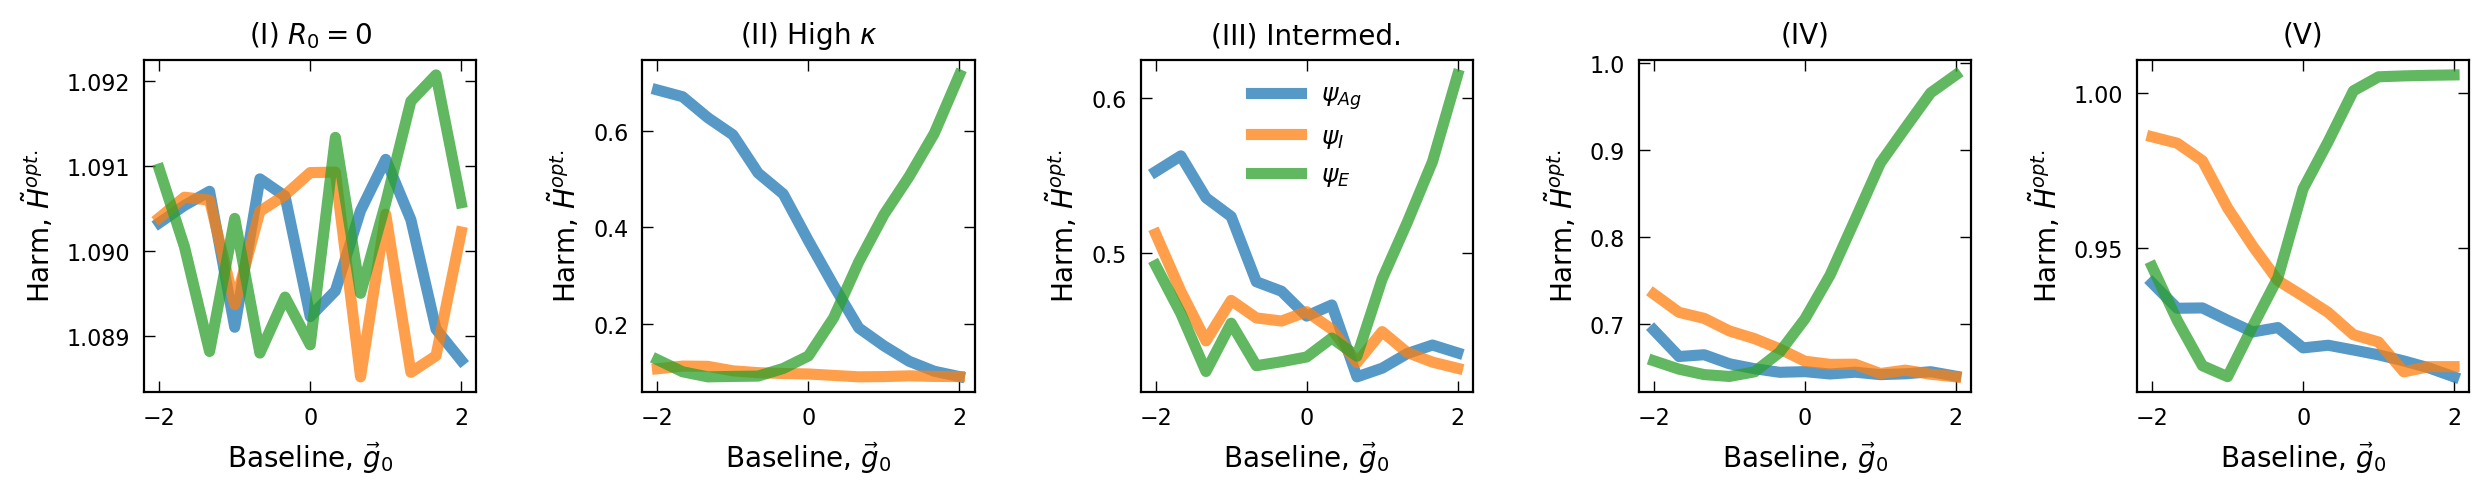

In [33]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars[0:3]):
        axs.flat[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
             g.loc[(g.ablate_index == i), [perf_vars[perf]]].values - 0*np.amin(g.loc[(g.ablate_index == i), [perf_vars[perf]]].values),
             color = cmap_colors[i], 
                         label = opt_vars_labels[i],
                            **kwargs)

        # axs.flat[k].scatter(g.loc[(g.ablate_index == 3 + i),  [var]].values,
        #                     g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values  - np.amin(g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values),
        #                     label = opt_vars_labels[3 + i],
        #                     color = cmap_colors[3 + i])

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[2].legend(fontsize=9, framealpha=0, ncol = 1)
axs.flat[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    # ax.set_xlim(-0.05, 1.05)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Harm, "+r'$\tilde{H}^{opt.}$', fontsize = 10)
    ax.set_xlabel(r"Baseline, $\vec g_0$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_feedback'+'.pdf', format="pdf", transparent=True, dpi=300)

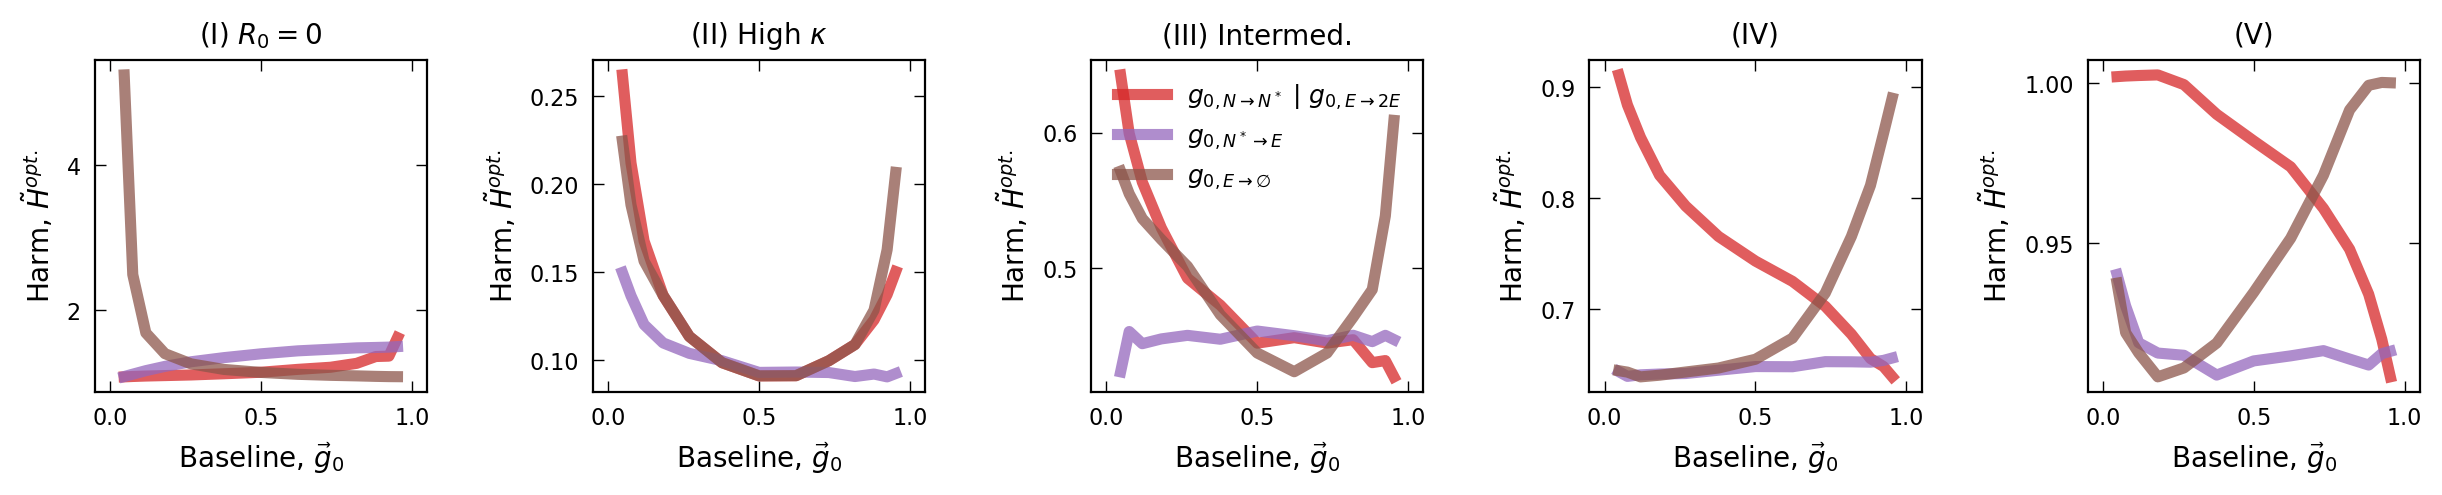

In [34]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars[3:]):
        axs.flat[k].plot(g.loc[(g.ablate_index == 3 + i),  [var]].values,
             g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values - 0*np.amin(g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values),
             color = cmap_colors[3 + i], 
                         label = opt_vars_labels[3 + i],
                            **kwargs)

        # axs.flat[k].scatter(g.loc[(g.ablate_index == 3 + i),  [var]].values,
        #                     g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values  - np.amin(g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values),
        #                     label = opt_vars_labels[3 + i],
        #                     color = cmap_colors[3 + i])

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[2].legend(fontsize=9, framealpha=0, ncol = 1)
axs.flat[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_xlim(-0.05, 1.05)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Harm, "+r'$\tilde{H}^{opt.}$', fontsize = 10)
    ax.set_xlabel(r"Baseline, $\vec g_0$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_baseline'+'.pdf', format="pdf", transparent=True, dpi=300)

Suggests that antigen and infection harm detection are fingible (once a response has been inititated).

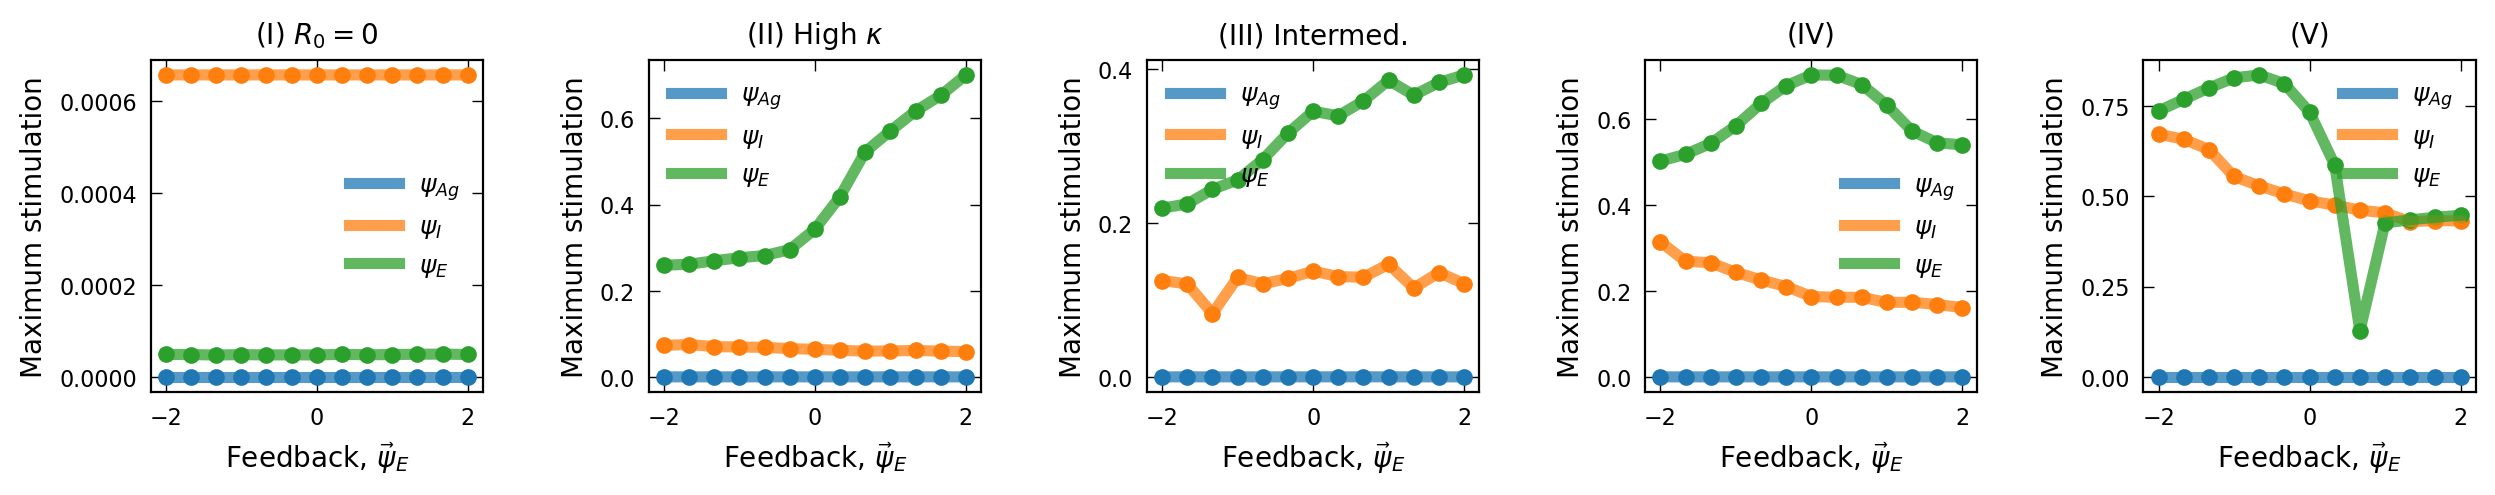

In [35]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    # (a) Effect of single parameter ablation on Infection
    normalize = np.amax(avg_cluster_data.loc[(avg_cluster_data.phase_cluster == k), stim])
    for i, var in enumerate(opt_vars):
        if i <= 2:
            axs[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i], 
                 label = opt_vars_labels[i],
                                **kwargs)

            axs[k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Maximum stimulation", fontsize = 10)
    ax.set_xlabel(r"Feedback, $\vec\psi_E$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_ablate'+'.pdf', format="pdf", transparent=True, dpi=300)

Figure above shows sensitive control with the anti-inflammatory signal is required to achieve high levels of Harm. Also, non-monotonic dependence on the activation pathway is observed.

The region of low sensitivity to the anti-inflammatory signal corresponds to biologically observed designs. In particular, it can be seen to drive the optima of the other design variables. Can I show this with correlations? What do we get out of looking at the baseline designs?

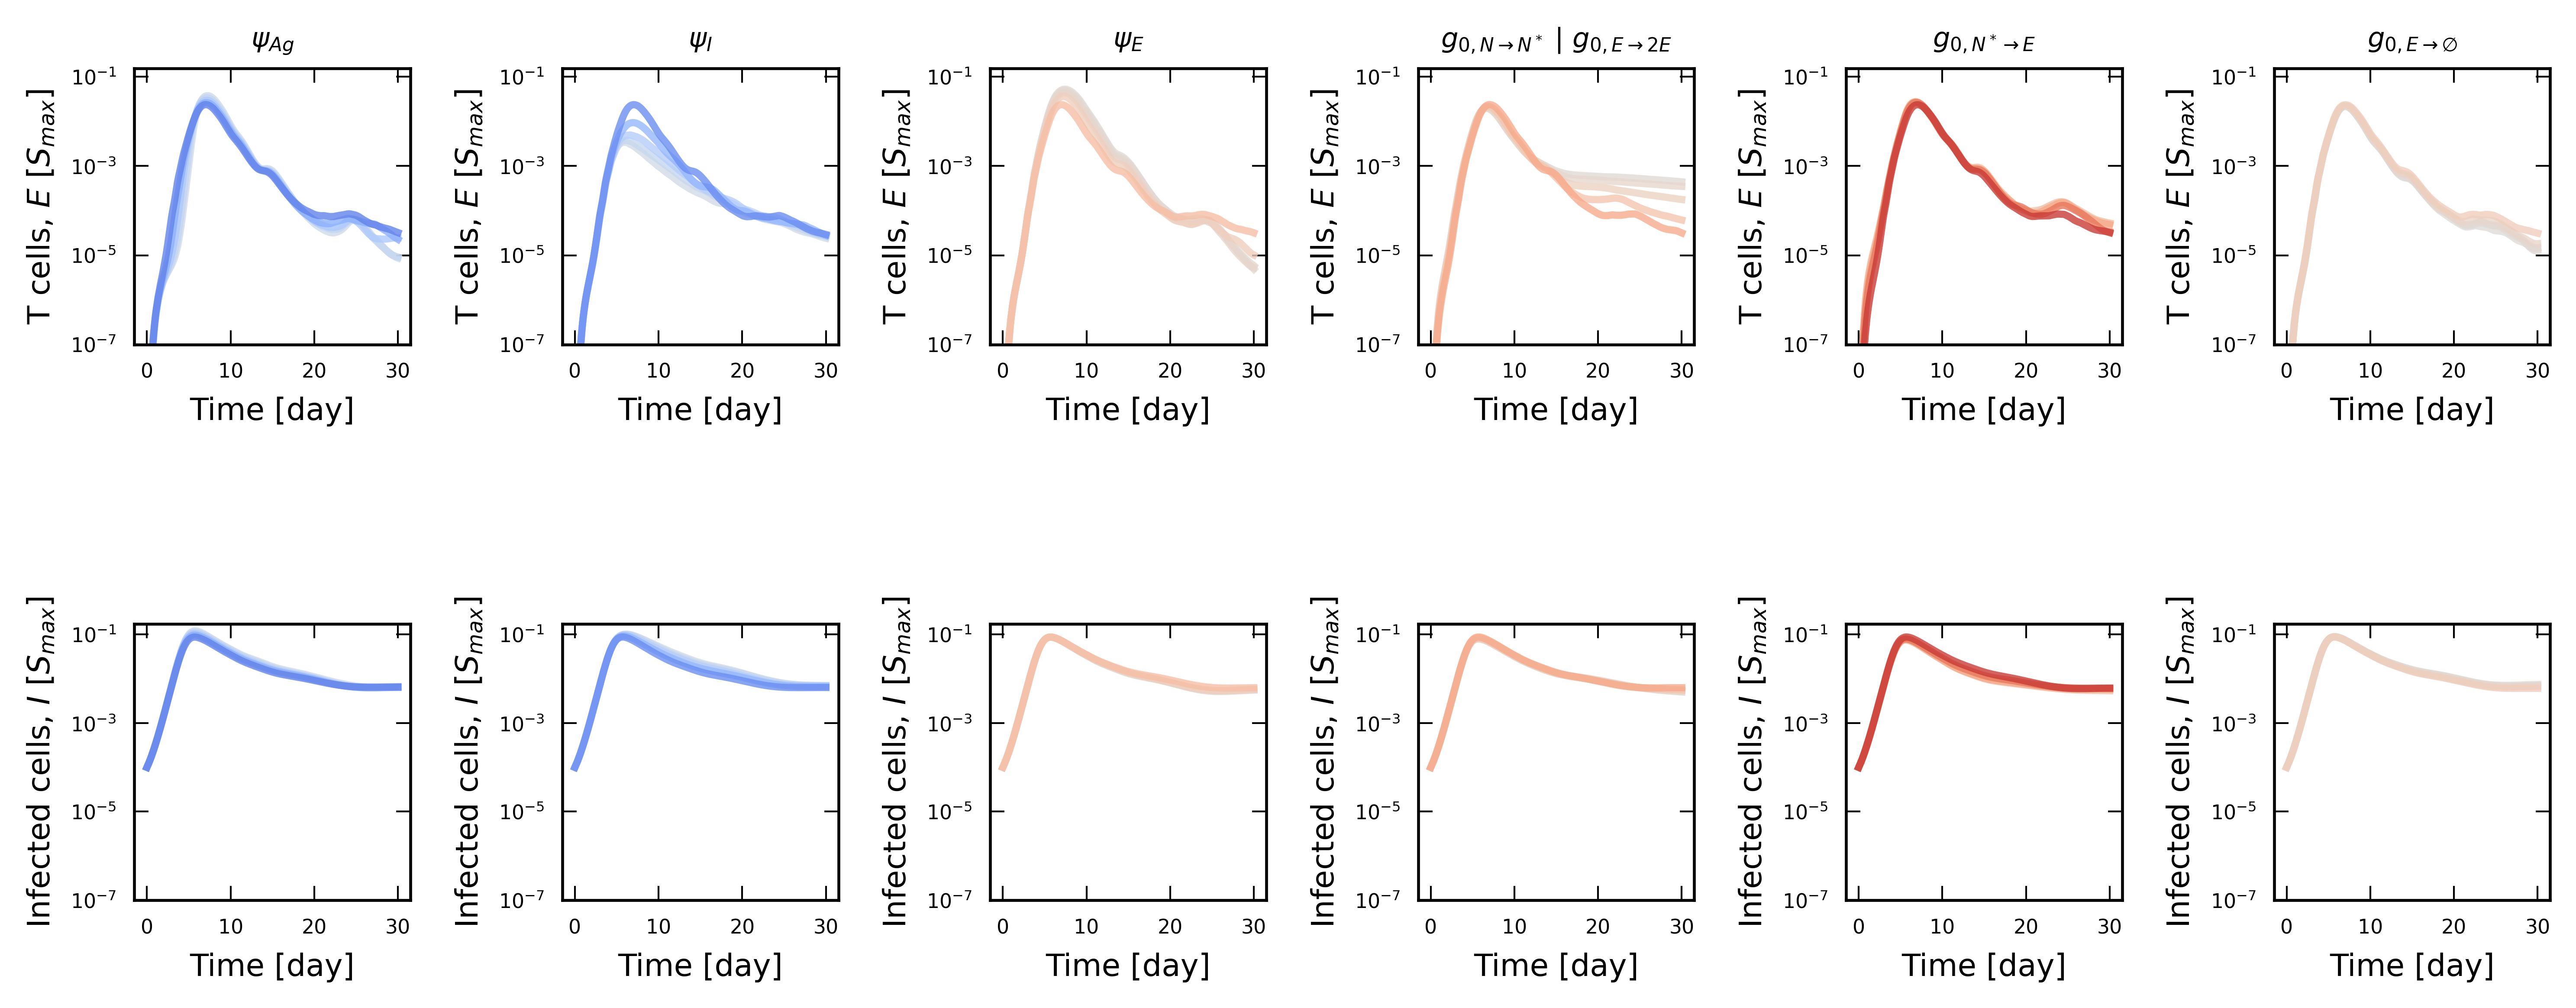

In [59]:
# Plot select infection responses
fig, axs = plt.subplots(2,len(opt_vars), dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*len(opt_vars), 5))
repeat = 10
select_cluster_data = np.tile(np.array(np.meshgrid(np.unique(cluster_input.d_I), # vary d_I
                                   np.unique(np.round(cluster_input.K_I, 3)), # vary K_I
                                   np.unique(np.round(cluster_input.b_I, 9)), # vary b_I
                                   np.unique(cluster_input.K_H), # vary K_H
                                   N_0*np.logspace(-2.0, 1.0, 5), # vary N_0
                                   np.unique(cluster_input.I_0) # vary I_0
                                           )).T.reshape(-1,6), (repeat, 1))
infection_count = len(select_cluster_data)
n_steps = 5
ps = np.tile(np.array(acute_pareto_reg.tolist() + [0.0]),  (n_steps*(len(acute_pareto_reg)), 1))

for i in np.arange(len(acute_pareto_reg)):
    ps[i*n_steps:(i+1)*n_steps, i] = ps[i*n_steps:(i+1)*n_steps, i]*np.logspace(-1.0, 0.0, n_steps)
    ps[i*n_steps:(i+1)*n_steps, -1] = i
    
store_Es = []
store_Is = []
store_runs = []

# Loop over pareto designs
for k, p in enumerate(ps):
    # loop over infections
    index = int(p[-1])
    dyn = 0

    single_ps_data = Parallel(n_jobs = num_cpu, 
                          batch_size = int(infection_count/repeat))(delayed(lin_stoch_sim)(N_0 = v[4],
                                                                  I_0 = v[5],
                                                                  b_I = v[2], 
                                                                  K_I = v[1],
                                                                  d_I = v[0],
                                                                  K_H = v[3],
                                                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                                                  infection_model = 'acute',
                                                                  reg_model = 'mwc_like',
                                                                  out_data = "full",
                                                                  memory_death = False,
                                                                  duration = 1.0*sim_duration,
                                                                  steps = 1*sim_steps)
                                                   for v in select_cluster_data
                                                  )

    dyn = sum([data_dict["cell_time_series"] for data_dict in single_ps_data])
    ts = single_ps_data[0]["time"]
    sim_summary = [data_dict["parameters"].tolist() + data_dict["summary_stats"].tolist() for data_dict in single_ps_data]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0]/infection_count, dyn[:,1]/infection_count, dyn[:,2]/infection_count, dyn[:, 3]/infection_count, dyn[:,4]/infection_count, dyn[:,5]/infection_count, dyn[:,6]/infection_count, dyn[:,7]/infection_count, dyn[:,8]/infection_count, dyn[:,9]/infection_count

    # Plot cell dynamics
    axs[0, index].plot(ts, E/S_0, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    axs[1, index].plot(ts, I/S_0, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    
    axs[0, index].set_title(opt_vars_labels[index], fontsize = 7.5)
    if index == 2:
        store_Es.append(E)
        store_Is.append(I)

    store_runs += sim_summary

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
out_df = pd.DataFrame(np.vstack(store_runs), columns = [i for i in var_names])
out_df.loc[:, 'R_0'] = np.round(out_df['S_0']*out_df['b_I']/out_df['d_I'] - 1,3)
out_df.loc[:, 'N_0'] = np.round(out_df['N_0'],3)
out_df.loc[:, 'kappa'] = np.round(out_df['S_0']/out_df['K_I'],3)
out_df.loc[:, opt_vars[0:3]] = out_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
out_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-out_df[reg_bl].values))
out_df.loc[:,"peff_total_harm"] = (out_df['harm_pI'] + out_df['harm_pS'])/S_0
out_df.loc[:,"peff_expE"] = out_df[perf_vars[3]]/out_df['N_0']

# # Save datasets
# d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/'
# d_file = d + '/sim_batch_-1-1-acute_ag-sim_vary_l0s.pkl'
# out_df.to_pickle(os.path.join(d, "raw", 'sim_batch_-1-1-acute_pareto-ablation.pkl'))

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j // len(opt_vars) == 0:
        ax.set_ylabel(r'T cells, $E$ [$S_{max}$]', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_0,)
    elif j // len(opt_vars) == 1:
        ax.set_ylabel(r'Infected cells, $I$ [$S_{max}$]', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_0,)
    elif j // len(opt_vars) == 2:
        ax.set_ylabel(r'Memory cells, $eM$', fontsize = 8.5)
        ax.set_xlabel("Time as\n effector [day]", fontsize = 8.5)
        #ax.semilogx()
        ax.semilogy()
        ax.set_ylim(1,)
    else:
        ax.set_xlabel(opt_vars_labels[j % len(opt_vars)], fontsize = 8.5)
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector dynamics", fontsize = 8.5)
        ax.set_yscale('symlog')

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.25)

plt.savefig('_figs/figSI_'+comment+'-pareto-design-ablate_prot-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

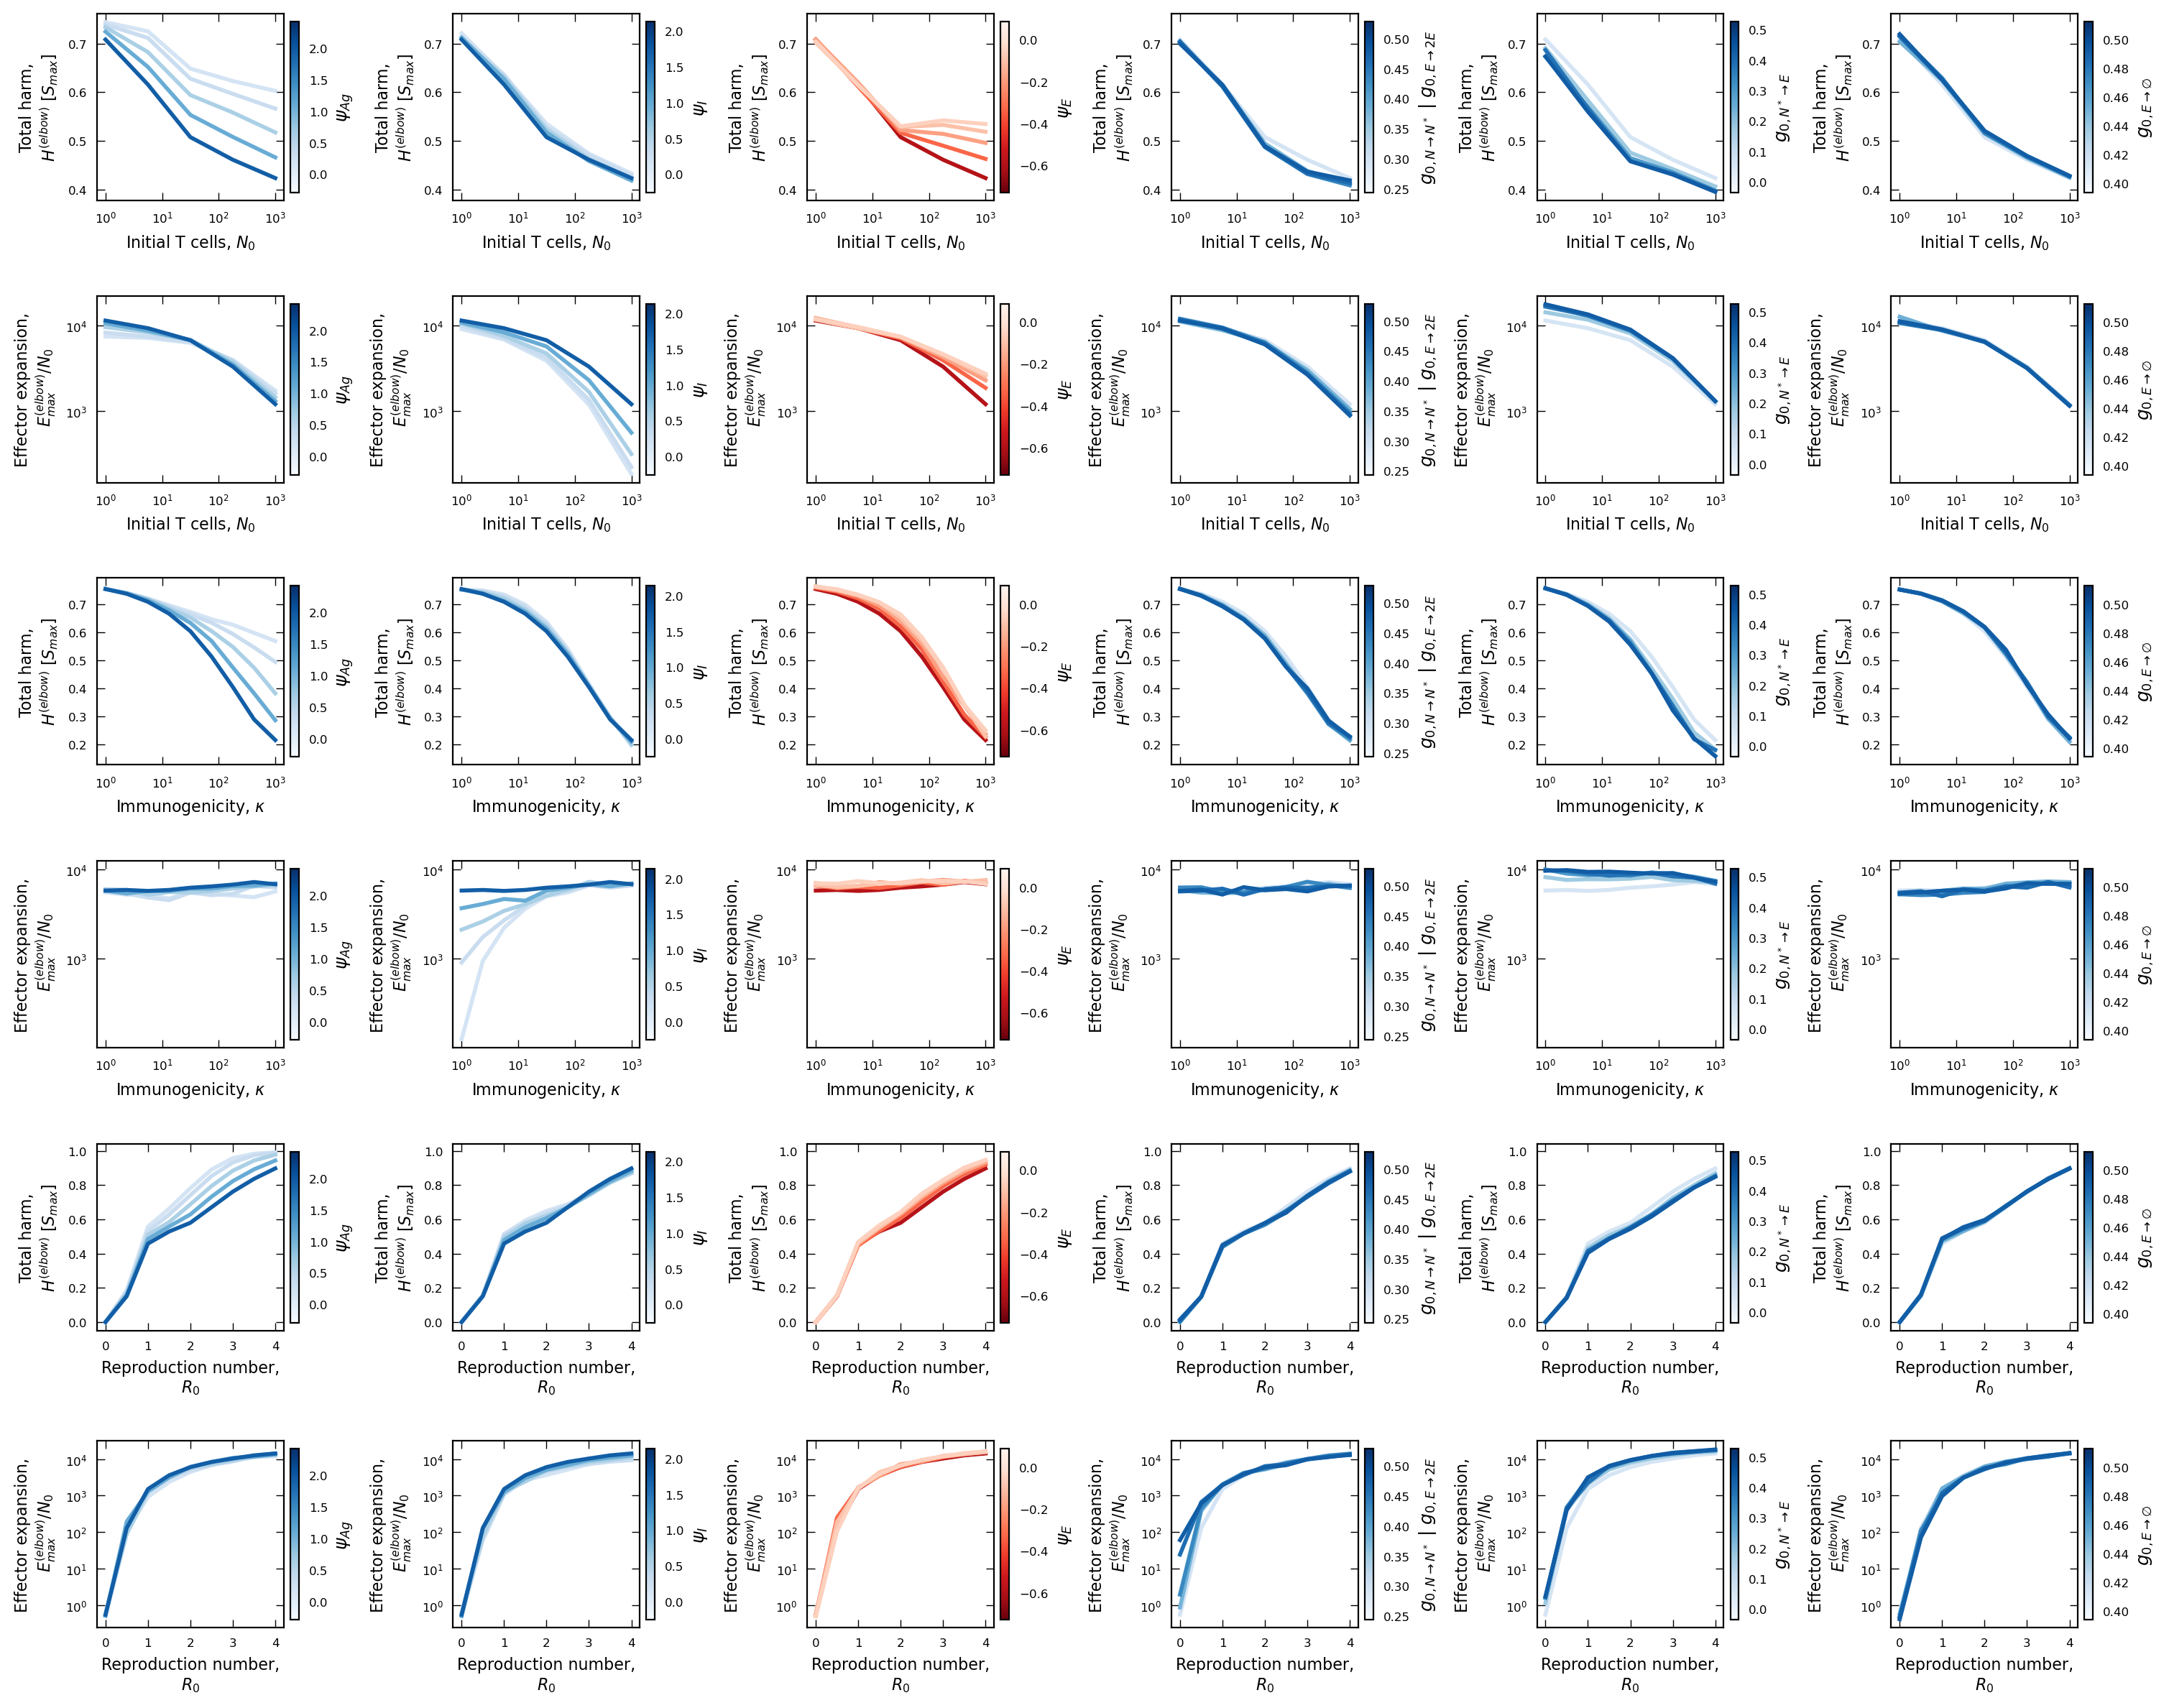

In [61]:
# Make trade-off figure
chosen_perf = ['peff_total_harm', 'peff_expE']
chosen_plots = ['N_0','kappa','R_0']
fig, axs = plt.subplots(len(chosen_plots)*len(chosen_perf),len(opt_vars), 
                        figsize=(len(chosen_plots)*len(chosen_perf)*2.5, len(opt_vars)*2.0), 
                        sharex='row', sharey='row',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, theta in enumerate(opt_vars):
    data = out_df.loc[np.sum(np.abs(out_df[opt_vars[0:3] + reg_bl].values - acute_pareto_reg), axis = 1) == np.abs(out_df[(opt_vars[0:3] + reg_bl)[k]].values - acute_pareto_reg[k])].groupby(chosen_plots + [theta], as_index = False).mean()
    sm = cm.ScalarMappable(norm = mcolors.Normalize(vmin=np.amin(out_df[theta]) - np.std(out_df[theta]), 
                                                    vmax=np.amax(out_df[theta]) + np.std(out_df[theta])), 
                           cmap=mpl.colormaps.get_cmap('Blues' if np.amax(out_df[theta]) > 0 else 'Reds_r'))
    # (a) Effect of single parameter ablation on Infection
    for i, v in enumerate(chosen_plots):
        use_data = data.groupby([v, theta], as_index = False).mean()
        color_arr = [choose_continous_color(x) for x in use_data[theta].values]
        for l, perf in enumerate(chosen_perf):

            for a in np.unique(use_data[theta].values):
                color = sm.to_rgba(a) #plt.cm.Reds(np.log(a)/np.log(np.amax(K_I_data.K_I)))
                axs[i*len(chosen_perf) + l, k].plot(use_data.loc[use_data[theta] == a][v], 
                                                    use_data.loc[use_data[theta] == a][perf],
                                                    linewidth = 2.0,
                                                    color = color)
            
            if l == 1:
                axs[i*len(chosen_perf) + l, k].semilogy()

            if i in [0, 1]:
                axs[i*len(chosen_perf) + l, k].semilogx()

            axs[i*len(chosen_perf) + l, k].set_xlabel(['Initial T cells, '+r'$N_0$', r'Immunogenicity, $\kappa$', 'Reproduction number,\n'+r'$R_0$'][i], fontsize = 8)
            axs[i*len(chosen_perf) + l, k].set_ylabel(['Total harm,\n'+r'$H^{(elbow)}$ [$S_{max}$]', 'Effector expansion,\n $E_{max}^{(elbow)}/N_0$'][l], fontsize = 8)
            cb = fig.colorbar(sm, ax=axs[i*len(chosen_perf) + l, k], location='right', shrink = 0.7, pad = 0.025)
            cb.set_label(opt_vars_labels[k], fontsize = 9)
            cb.ax.tick_params(labelsize=6)

    # axs[0,k].set_title(opt_vars_labels[k], fontsize = 10.0)
    
#axs.flat[1].legend(fontsize=8, framealpha=0, ncol = 1)
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=6)
    #ax.locator_params(axis='y', nbins=4)
    # ax.semilogy()
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    # if j // 3 == 0:
    #     ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.savefig('_figs/fig5_'+comment+'-perf_perturb_design'+'.pdf', format="pdf", transparent=True, dpi=300)

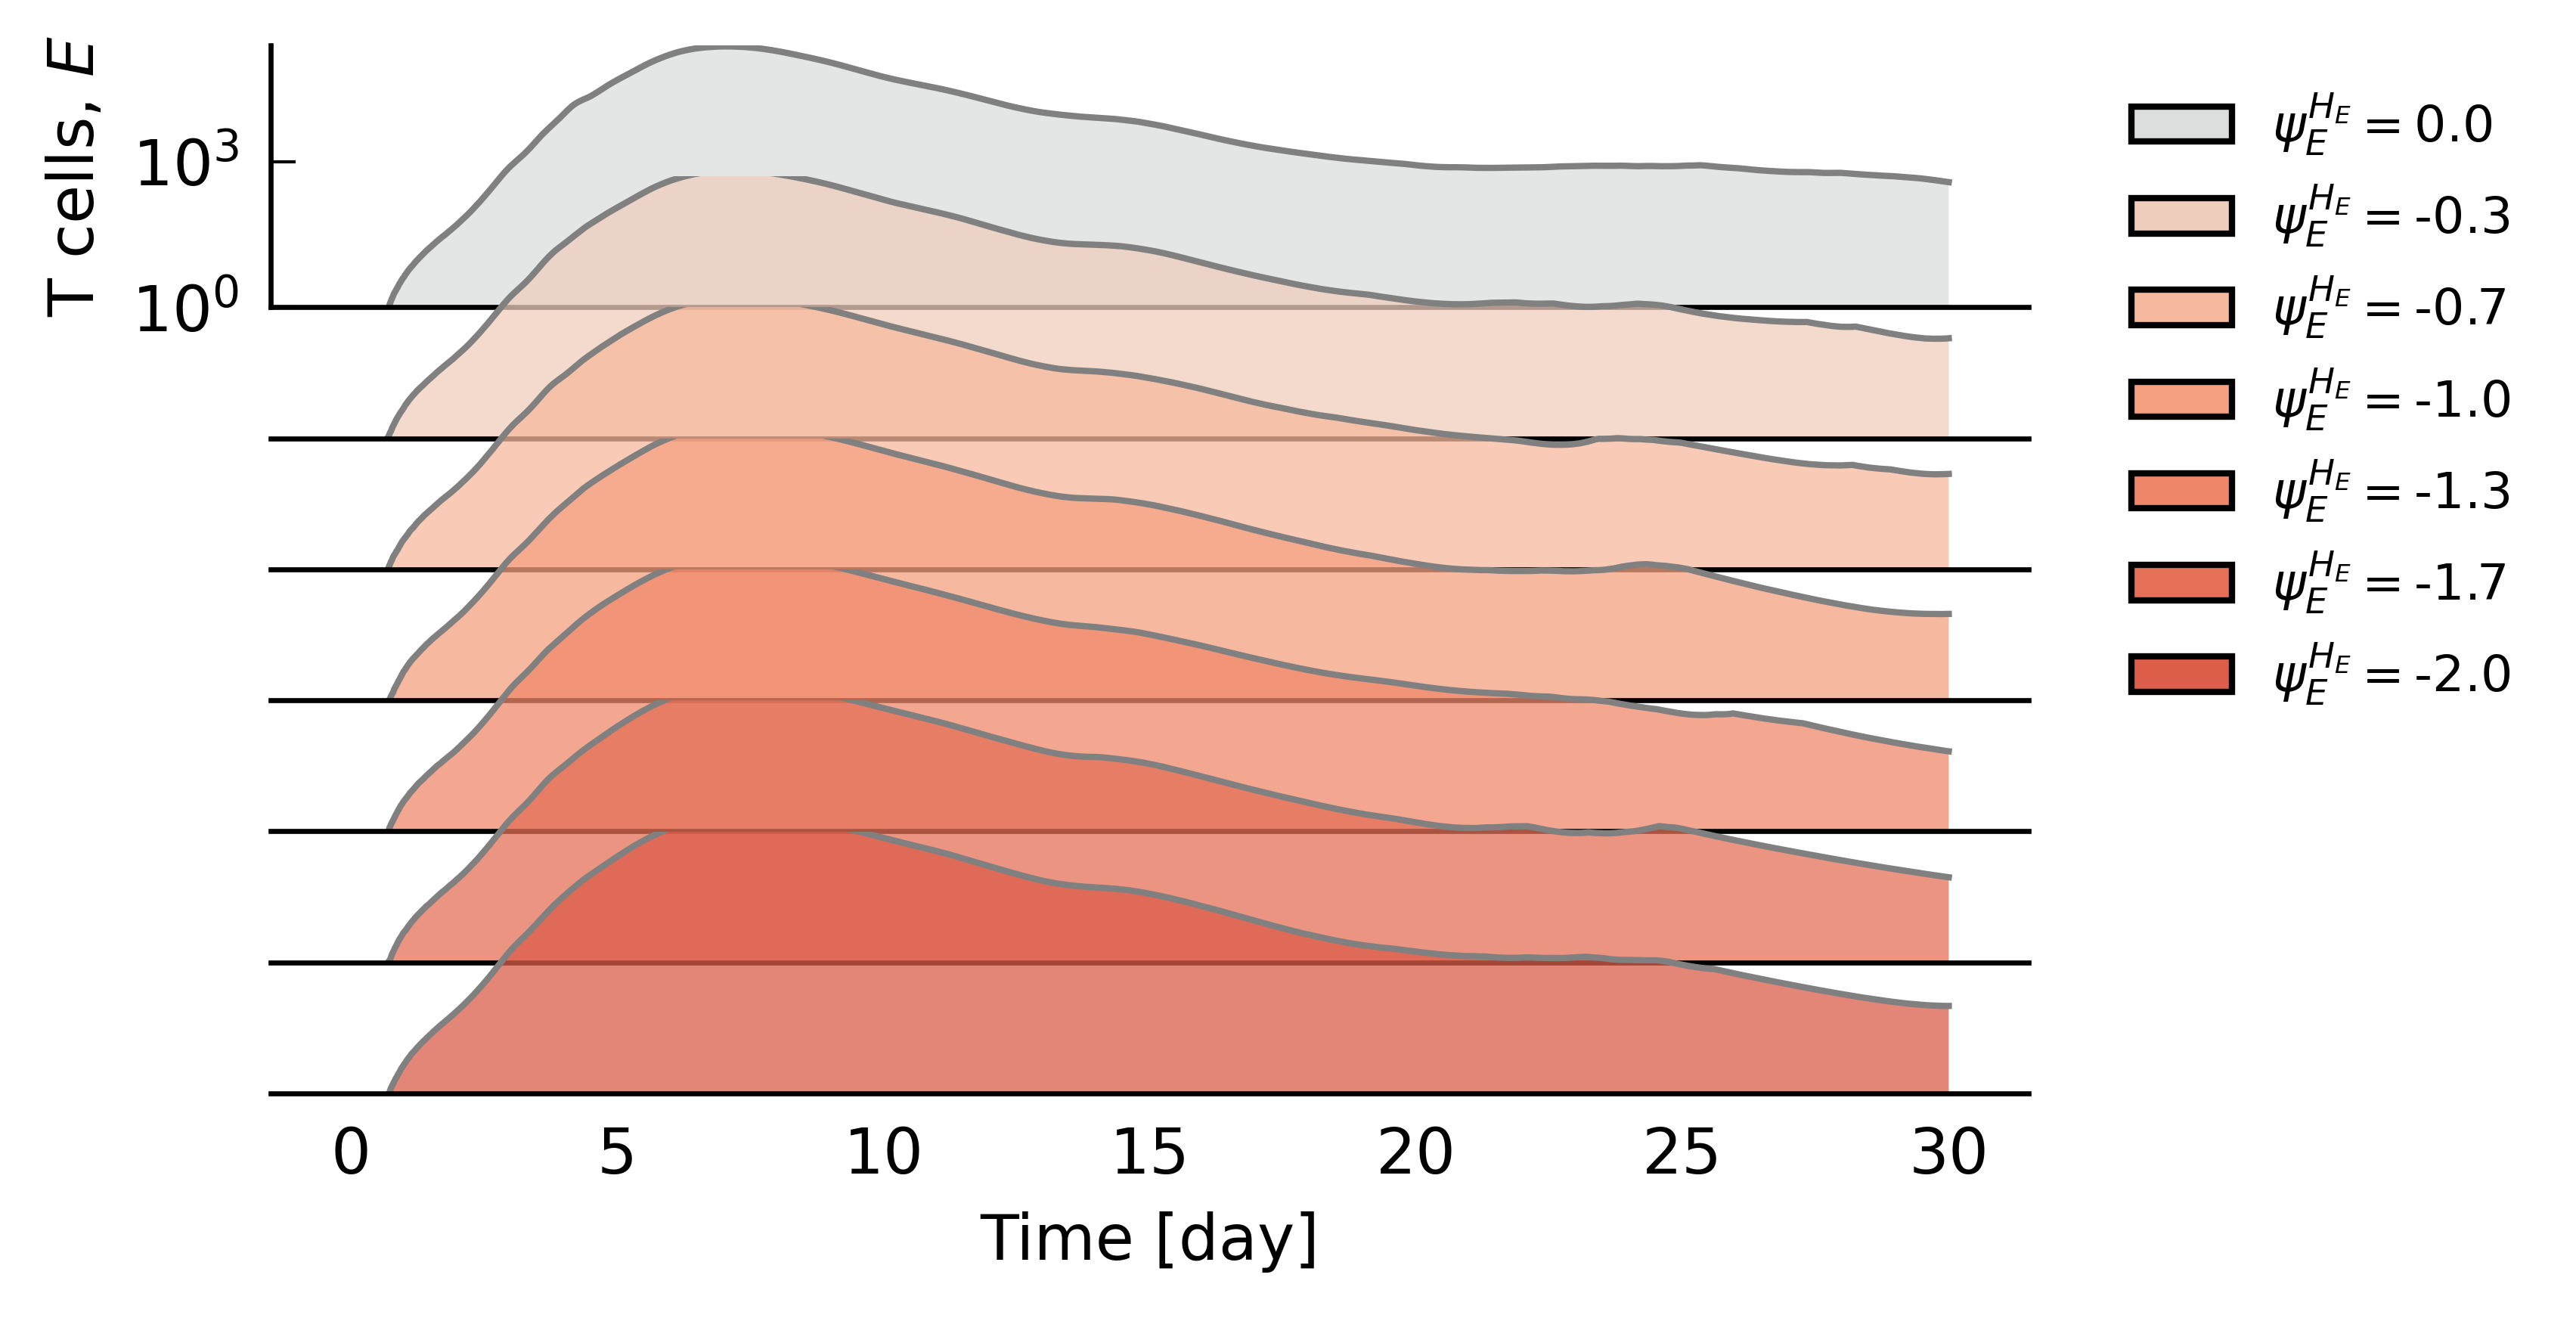

In [38]:
xs = ts

ps_HE = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.phase_cluster == 1)*(cluster_ablate_grid_opt.ablate_index == 2)*(cluster_ablate_grid_opt[opt_vars[2]] <= 0)][opt_vars[2]].tolist()[::-1]
#ps_HE = [p for k, p in enumerate(cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index == 2)][opt_vars].values[:,2])  if (k % 4 == 0)][::-1]
ys = store_Es[:len(ps_HE)][::-1]
zs = store_Is[:len(ps_HE)][::-1]

labels = [r"$\psi_E^{H_E} = $" + str(np.round(p, 1)) for p in ps_HE]

# Plotting code.
ncols = 1
nrows = len(ys)

fig, axes = plt.subplots(
    ncols=ncols, nrows=nrows, sharex=True, sharey=True, dpi=300,
    figsize=(5, 3), subplot_kw={"facecolor": (0, 0, 0, 0), "frameon": True},
    # Control how much axes overlap onto one another.
    gridspec_kw={"hspace": -0.5}, 
)

legend_handles = []

for idx, (y, ax) in enumerate(zip(ys, axes)):
    color = plt.cm.coolwarm_r(1/(1 + np.exp(-ps_HE[idx]))) #plt.colormaps["coolwarm"](idx / nrows)

    # Add black line to top of distribution.
    ax.plot(xs, y, color='grey', linewidth=1.0)
    # ax.plot(xs, zs[idx], color='k', linewidth=2.0, label = r"Infected cells, $I$" if idx == 0 else '')
    ax.set_ylim(1,None)
    ax.semilogy()
    #ax.semilogx()

    # Add black line to bottom of distribution.
    # Change min_vals to what it should be. E.g., log scale should be min_vals = 1
    min_vals = np.zeros_like(xs)
    #ax.plot(xs, min_vals, color='k', linewidth=1)

    # Create fill distributions. Alpha 
    ax.fill_between(
        xs, y, alpha=0.75, color=color, label=labels[idx],
        linewidth=0
    )
    ax.tick_params(
        right=False, top=False, left=False, bottom=False, which="both",
        # Turn off y-axis labels.
        labelleft=False
    )
    ax.spines.top.set_visible(False)
    ax.spines.left.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.spines.bottom.set_visible(True)

    patch_for_legend = plt.matplotlib.patches.Patch(
        facecolor=color, edgecolor='k', label=labels[idx]
    )
    legend_handles.append(patch_for_legend)

axes[0].tick_params(bottom=True)
axes[0].spines.bottom.set_visible(True)
axes[0].tick_params(
    right=False, top=False, left=True, bottom=False, which="both",
    # Turn off y-axis labels.
    labelleft=True
)
axes[0].spines.left.set_visible(True)
axes[-1].set_xlabel("Time [day]", fontsize = 10)
axes[0].set_ylabel('T cells, '+ r'$E$', fontsize = 10)

axes[0].legend(
    handles=legend_handles, framealpha=0,
    # Adjust location of legend.
    bbox_to_anchor=(1.3, 1.0),
    fontsize=8
)

#plt.show()

plt.savefig('_figs/figSI_'+comment+'-pareto-design-ablate_prot-eff-dynamics-splines'+'.pdf', format="pdf", transparent=True, dpi=300)

In [39]:
from optimize_nets import *

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

pnts = 9
vary_l0s = np.array(list(itertools.product(np.linspace(-L0_max, L0_max, pnts).tolist(),
                                          np.linspace(-L0_max, L0_max, pnts).tolist(),
                                          np.linspace(-L0_max, L0_max, pnts).tolist())))

input_regs = np.array([-0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,0], # Na
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,1], # NE
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], -L0_max**4 -0*vary_l0s[:,1], # EM
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,2]]).T  # Edie

# run(batch = [-1], outdir=d, inf_sample = cluster_input[['d_I', 'K_I', 'b_I', 'K_H', 'N_0','I_0']].values, 
#     comment="sim_vary_l0s", runs = 1, infection_model = 'acute_ag', default_reg = input_regs, 
#     num_cpu = num_cpu, run_time = 10)

d_file = d + '/sim_batch_-1-1-acute_ag-sim_vary_l0s.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
vary_l0s_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]).merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

vary_l0s_data.loc[:, 'R_0'] = vary_l0s_data['S_0']*vary_l0s_data['b_I']/vary_l0s_data['d_I'] - 1
vary_l0s_data.loc[:,'exp_rate'] = np.log(np.maximum(vary_l0s_data['max_pE'], max_Na)/max_Na)/np.maximum(t_cycle, vary_l0s_data['T_pE_max'] - vary_l0s_data['T_pE_start'])
vary_l0s_data.loc[:,'end_rate'] = -np.log(np.maximum(vary_l0s_data['N_0'], vary_l0s_data['E_end'])/np.maximum(vary_l0s_data['N_0'], vary_l0s_data['max_pE']))/np.maximum(t_cycle, vary_l0s_data['T_pE_end'] - vary_l0s_data['T_pE_max'])
vary_l0s_data.loc[:,'max_expE'] = vary_l0s_data['max_pE']/vary_l0s_data['N_0']
vary_l0s_data.loc[:,opt_vars[0:3]] = np.round(vary_l0s_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
vary_l0s_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-vary_l0s_data[reg_bl].values)), 3)
vary_l0s_data.loc[:,"harm_pI_noprotection"] = vary_l0s_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

vary_l0s_data.loc[:,"peff_infection"] = vary_l0s_data['harm_pI']/S_0
vary_l0s_data.loc[:,"peff_toxicity"] = vary_l0s_data['harm_pS']/S_0
vary_l0s_data.loc[:,"peff_scaled_total_harm"] = (vary_l0s_data['peff_infection'] + vary_l0s_data['peff_toxicity'])/vary_l0s_data['harm_pI_noprotection']

vary_eff_dyn_design = vary_l0s_data.groupby(opt_vars, as_index = False, sort = False).mean()

# with pd.option_context('display.max_columns', None):
#     display(prot_eff_dyn_design)

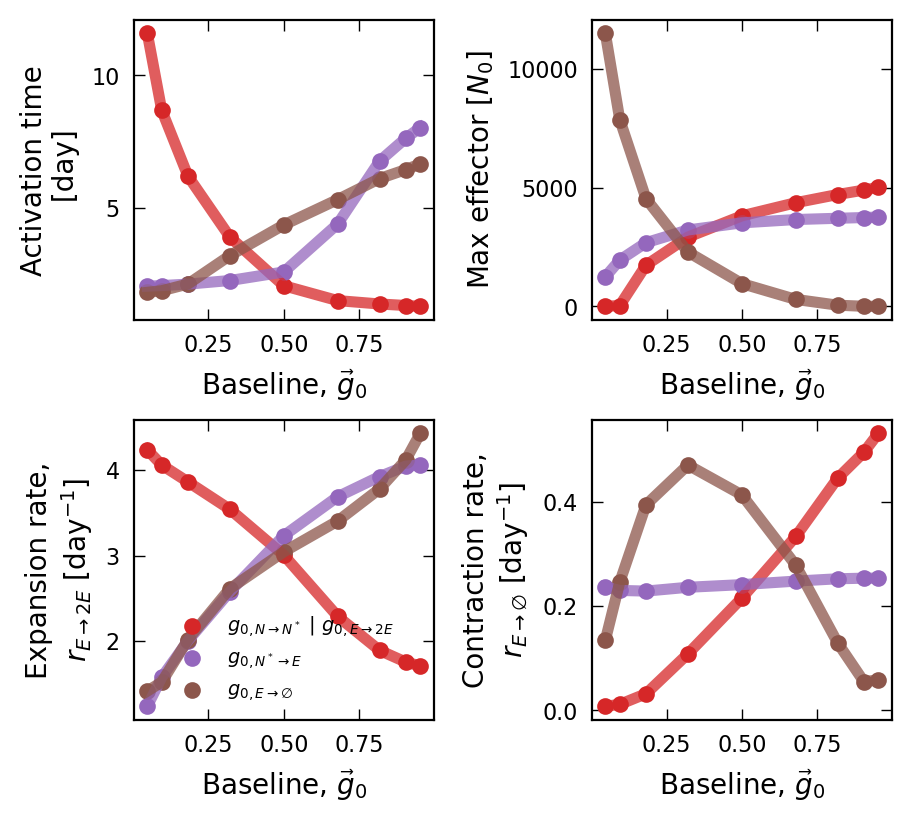

In [40]:
# Plot dependency of effector dynamics on design
eff_dyn_vars = ['T_pE_start', 'max_expE', 'exp_rate', 'end_rate']#, 'E_end', 'peff_infection'] #'exp_rate', , 'sel_ratio'
eff_dyn_labels = ['Activation time\n [day]', 'Max effector '+ r'[$N_0$]', 'Expansion rate,\n'+r'$r_{E \to 2E}$ [$\text{day}^{-1}$]', 
                  'Contraction rate,\n'+r'$r_{E \to \emptyset}$ [$\text{day}^{-1}$]'] #,'Final effector'+ r'[$N_0$]', perf_labels[1]+r' [$S_{max}$]'] # 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', , 'Response avidity'

# Make trade-off figure
fig, axs = plt.subplots(2, 2,figsize=(4.5, 4), sharex='row', sharey=False, layout='constrained')

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, (eff_var, ax) in enumerate(zip(eff_dyn_vars, axs.flat)):

    # (a) Effect of single parameter ablation on Harm
    for i, var in enumerate(opt_vars[3:]):
        plot_data = vary_eff_dyn_design.groupby([var], as_index = False).mean()
        
        ax.plot(np.abs(plot_data[var].values),
                plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                color = cmap_colors[3 + i], 
                            **kwargs)

        ax.scatter(np.abs(plot_data[var].values),
                   plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                   label = opt_vars_labels[3 + i], # (r"$-$" if i == 2 else '')+
                   color = cmap_colors[3 + i])
        
    if k == 2:
        ax.legend(fontsize=7, framealpha=0, ncol = 1) # bbox_to_anchor=(1.0, 1), 
    
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    ax.locator_params(axis='x', nbins=4)
    if 'exp.' not in eff_dyn_labels[k]:
        ax.locator_params(axis='y', nbins=4)
    else:
        ax.semilogy()

    ax.minorticks_off()
    #ax.set_ylim(0, None)
    ax.set_ylabel(eff_dyn_labels[k], fontsize = 10)
    ax.set_xlabel(r"Baseline, $\vec g_0$", fontsize = 10)
    
#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-design-vary_prot-eff-dynamics-simple'+'.pdf', format="pdf", transparent=True, dpi=300)

The strong negative effect of down-regulation with the anti-inflammatory signal is a strong argument for why it may be in the regime of weak regulation. In some ways the anti-inflammatory signal can be auto-regulatory.

Also, plot performance of optimal acute response designs while varying anti-inflammatory sensitivity, along with the performance of these same designs in other scenarios. Probably want to normalize Harm by Infection.

A strong antigen response causes a lot of toxicity when applied to a weak antigen. But the response can be adjusted.

Optimal designs switch between modes of Infection and containment of the infection. How can I show this more suscinctly? Maybe focus on the time it takes for the infection to clear? Maybe sample design space and do clustering/low dimensional embedding of the 4 effector dynamics variables and then look within those clusters?

Maybe only relevant when we focus in on the anti-inflammatory feedback and the naive to effector pathway for Ag. dominant infections. This figure is about trade-offs.

#### Application to a model of autoimmune triggers

In [41]:
# Define variables and dataframes
zeroR0_plots = [vir_vars[6], vir_vars[4]]
zeroR0_plot_labels = ["Perturbation [$S_{max}$]", r"Dosage [$S_{max}$]"]

In [73]:
from optimize_nets import *
num_pnts = 5
runs = 5

sample = np.array(np.meshgrid(np.array([0.5]), # vary d_I
                                   S_0*np.logspace(-3.0, 0, num_pnts), # vary K_I
                                   b_I*np.linspace(0.5, 1.5, num_pnts), # vary b_I
                                   K_H*np.logspace(-1.0, 1.0, num_pnts), # vary K_H
                                   N_0*np.logspace(-2.0, 1.0, num_pnts), # vary N_0
                                   I_min*np.logspace(0, 2.0, num_pnts) # vary I_0
                                           )).T.reshape(-1,6)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
modified_acute_pareto_reg = acute_pareto_reg #*np.array([1.0,0.1,1.0,1.0,1.0,1.0])
modified_acute_pareto_reg[1] = np.unique(out_df[opt_vars[1]])[0]

ps = np.array([[modified_acute_pareto_reg[0], modified_acute_pareto_reg[1], modified_acute_pareto_reg[2], modified_acute_pareto_reg[3], # Na
          modified_acute_pareto_reg[0], modified_acute_pareto_reg[1], modified_acute_pareto_reg[2], modified_acute_pareto_reg[4], # NE
          -0*modified_acute_pareto_reg[0], -0*modified_acute_pareto_reg[1], -0*modified_acute_pareto_reg[2], -L0_max**3 -0*modified_acute_pareto_reg[4], # EM
          -modified_acute_pareto_reg[0], -modified_acute_pareto_reg[1], -modified_acute_pareto_reg[2], modified_acute_pareto_reg[5]]])  # Edie

# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample, 
    comment="zeroR0_acute_comp_sim", runs = runs, infection_model = 'acute', 
    default_reg = ps,
    num_cpu = num_cpu)

Running 15625 simulations in batch #-1
Saved sim_batch_-1-5-acute-zeroR0_acute_comp_sim.pkl
0.07652886185381147 hrs


In [74]:
d_file = d + '/sim_batch_-1-5-acute-zeroR0_acute_comp_sim.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
zeroR0_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(vir_vars, as_index=False).mean()

# compute infection harm without T cell response
zeroR0_acute_comp_df.loc[:,opt_vars[0:3]] = zeroR0_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
zeroR0_acute_comp_df.loc[:, 'R_0'] = zeroR0_acute_comp_df['S_0']*zeroR0_acute_comp_df['b_I']/zeroR0_acute_comp_df['d_I'] - 1
zeroR0_acute_comp_df.loc[:,"peff_infection"] = zeroR0_acute_comp_df['harm_pI'].to_numpy()/S_0
zeroR0_acute_comp_df.loc[:,"peff_toxicity"] = zeroR0_acute_comp_df['harm_pS'].to_numpy()/S_0
zeroR0_acute_comp_df.loc[:,"peff_total_harm"] = zeroR0_acute_comp_df['peff_infection'] + zeroR0_acute_comp_df['peff_toxicity']
zeroR0_acute_comp_df.loc[:,'max_expE'] = zeroR0_acute_comp_df['max_pE']/zeroR0_acute_comp_df['N_0']

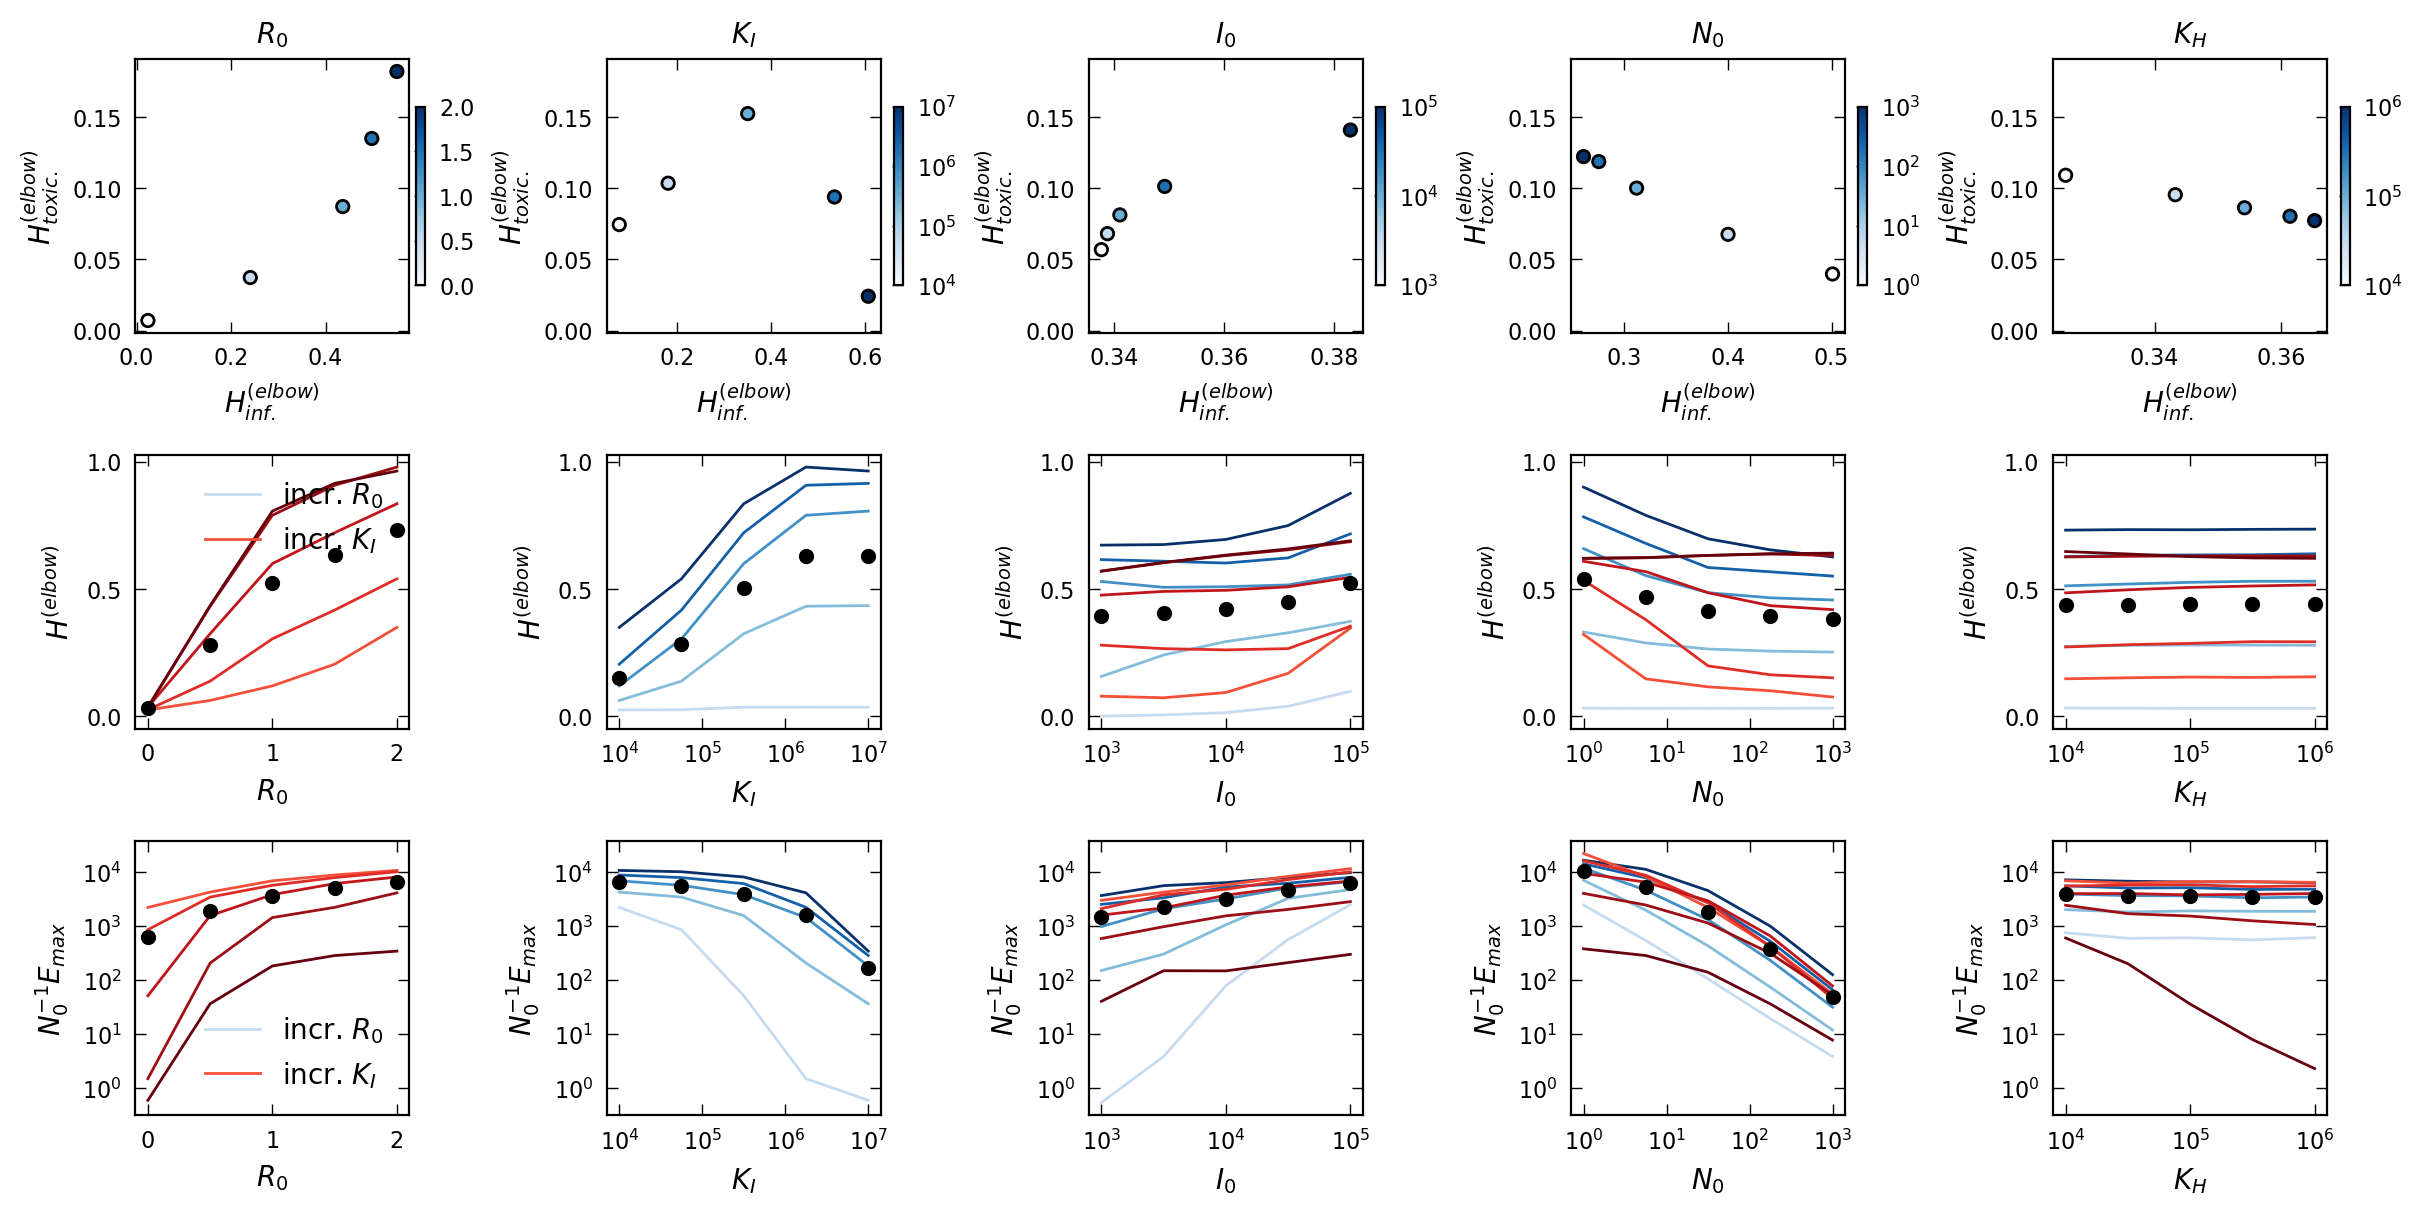

In [75]:
# Visualize optimal Harm and regulation
parameters = ['R_0', 'K_I', 'I_0', 'N_0', 'K_H']

fig, axs = plt.subplots(3, len(parameters), 
                          figsize=(2*len(parameters) + 2, 6), sharex=False, sharey='row', constrained_layout=True)


for k, var in enumerate(parameters):

    data = zeroR0_acute_comp_df.groupby([var],as_index = False).mean()
    R_0_data = zeroR0_acute_comp_df.groupby([var] + (['R_0'] if var != 'R_0' else []),as_index = False).mean()
    K_I_data = zeroR0_acute_comp_df.groupby([var] + (['K_I'] if var != 'K_I' else []),as_index = False).mean()

    z = data[var].values
    range = np.amax(np.abs(z))
    im = axs[0,k].scatter(data.peff_infection, data.peff_toxicity,
                 marker ='o', s = 20, c = z, 
                 cmap='Blues', edgecolors = 'black',# alpha = 0.8, 
                 norm = mpl.colors.LogNorm(vmax = range) if var not in ['d_I','R_0'] else mpl.colors.Normalize())

    axs[1,k].scatter(data[var], data.peff_total_harm,
                 marker ='o', s = 20, color = 'black', zorder = 3)
    # axs[1,k].plot(max_data[var], max_data.peff_total_harm,
    #              color = 'grey')
    # axs[1,k].plot(min_data[var], min_data.peff_total_harm,
    #              color = 'grey')

    axs[2,k].scatter(data[var], data.max_expE,
                 marker ='o', s = 20, color = 'black', zorder = 3)
    for l,a in enumerate(np.unique(R_0_data.R_0)):
        color = plt.cm.Blues(0.25 + 0.75*a/np.amax(R_0_data.R_0))
        axs[2,k].plot(R_0_data.loc[R_0_data.R_0 == a][var], R_0_data.loc[R_0_data.R_0 == a].max_expE,
                     color = color, label = 'incr. $R_0$' if l == 0 else '')

        axs[1,k].plot(R_0_data.loc[R_0_data.R_0 == a][var], R_0_data.loc[R_0_data.R_0 == a].peff_total_harm,
                     color = color, label = 'incr. $R_0$' if l == 0 else '')

    for l,a in enumerate(np.unique(K_I_data.K_I)):
        color = plt.cm.Reds(np.log(a)/np.log(np.amax(K_I_data.K_I)))
        axs[2,k].plot(K_I_data.loc[K_I_data.K_I == a][var], K_I_data.loc[K_I_data.K_I == a].max_expE,
                     color = color, label = 'incr. $K_I$' if l == 0 else '')

        axs[1,k].plot(K_I_data.loc[K_I_data.K_I == a][var], K_I_data.loc[K_I_data.K_I == a].peff_total_harm,
                     color = color, label = 'incr. $K_I$' if l == 0 else '')
    # axs[2,k].plot(min_data[var], min_data.max_expE,
    #              color = 'grey')

    z_label = r'$'+parameters[k]+'$'
    axs[0,k].set_title(z_label, fontsize = 10.0)
    axs[0,k].set_xlabel(r'$H_{inf.}^{(elbow)}$', fontsize = 10)
    axs[0,k].set_ylabel(r'$H_{toxic.}^{(elbow)}$', fontsize = 10)
    cb = fig.colorbar(im, ax=axs[0,k], location='right', shrink = 0.6, pad = 0.025)
    cb.ax.tick_params(labelsize=8)
    #axs[0,k].locator_params(axis='y', nbins=4)

    if var not in ['d_I','R_0']:
        axs[1,k].semilogx()
    axs[1,k].set_xlabel(z_label, fontsize = 10)
    axs[1,k].set_ylabel(r'$H^{(elbow)}$', fontsize = 10)
    axs[1,k].locator_params(axis='y', nbins=4)
    axs[1,0].legend()

    if var not in ['d_I','R_0']:
        axs[2,k].semilogx()
    axs[2,k].semilogy()
    axs[2,k].set_xlabel(z_label, fontsize = 10)
    axs[2,k].set_ylabel(r'$N_0^{-1}E_{max}$', fontsize = 10)
    axs[2,0].legend()


for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-elbow-parameter-sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Application to a model of a fast-growing tumor

In [45]:
# Define variables and dataframes
cancer_plots = [vir_vars[1], vir_vars[0], vir_vars[4]]
cancer_plot_labels = [r"Immunogenicity, $\kappa$", r"Initial T cells, $N_0$ [$S_{max}$]"]

cancers_labels = ['Lower ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1]]

cancers_labels_indent = ['Lower ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1]]

There a sort of goldilocks effect where the designs for cancer Harm are suboptimal for acute response but the worst designs those of intermediate Immunogenicity.

##### Compute tumour Harm of Ag. dominant pareto Harm

In [76]:
from optimize_nets import *
num_pnts = 15
runs = 10
sample = np.array(np.meshgrid(d_S*np.array([1.0]), # vary d_I
                                   S_0*np.logspace(-3.0, 0.0, num_pnts), # vary K_I
                                   b_C*np.array([1.0]), # vary b_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-2.0, 2.0, num_pnts), # vary N_0
                                   S_0*np.array([0.1]), # vary I_0
                                   np.array([S_0]) # vary K_S
                                           )).T.reshape(-1,7)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

h = 1e-1
arr = np.arange(0, len(modified_acute_pareto_reg))
ps = np.vstack([[modified_acute_pareto_reg - h*(arr == j), modified_acute_pareto_reg, modified_acute_pareto_reg + h*(arr == j)] for j, a in enumerate(arr)])
cancer_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample, 
    comment="ag_dosage_sim", runs = runs, infection_model = 'cancer', 
    default_reg = cancer_psis,
    num_cpu = num_cpu)

Running 40500 simulations in batch #-1
Saved sim_batch_-1-10-cancer-ag_dosage_sim.pkl
0.3885261477364434 hrs


In [77]:
d_file = d + '/sim_batch_-1-10-cancer-ag_dosage_sim.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(cancer_plots + reg, as_index=False).mean()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_0
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']

In [78]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - modified_acute_pareto_reg), axis = 1) == 0]
opt_N0 = data.loc[data.groupby('K_I')['peff_total_harm'].idxmin()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))
fixed_N0 = data.loc[data.groupby('K_I')['N_0_match'].idxmin()].copy() #np.amax(data['N_0'])

# Compute effect of perturbation in the design
gradients = []
for k, (a,b) in enumerate(fixed_N0[['K_I', 'N_0']].values):
    input = cancer_acute_comp_df.loc[(cancer_acute_comp_df.K_I == a)*(cancer_acute_comp_df.N_0 == b)].copy()
    input.loc[:,'dummy'] = np.sum(np.abs(input.copy()[opt_vars[0:3] + reg_bl].values - modified_acute_pareto_reg), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        out[i] += grad[1]

    gradients.append(out)

gradients_data = np.vstack(gradients)

/tmp/ipykernel_38076/1932553009.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))


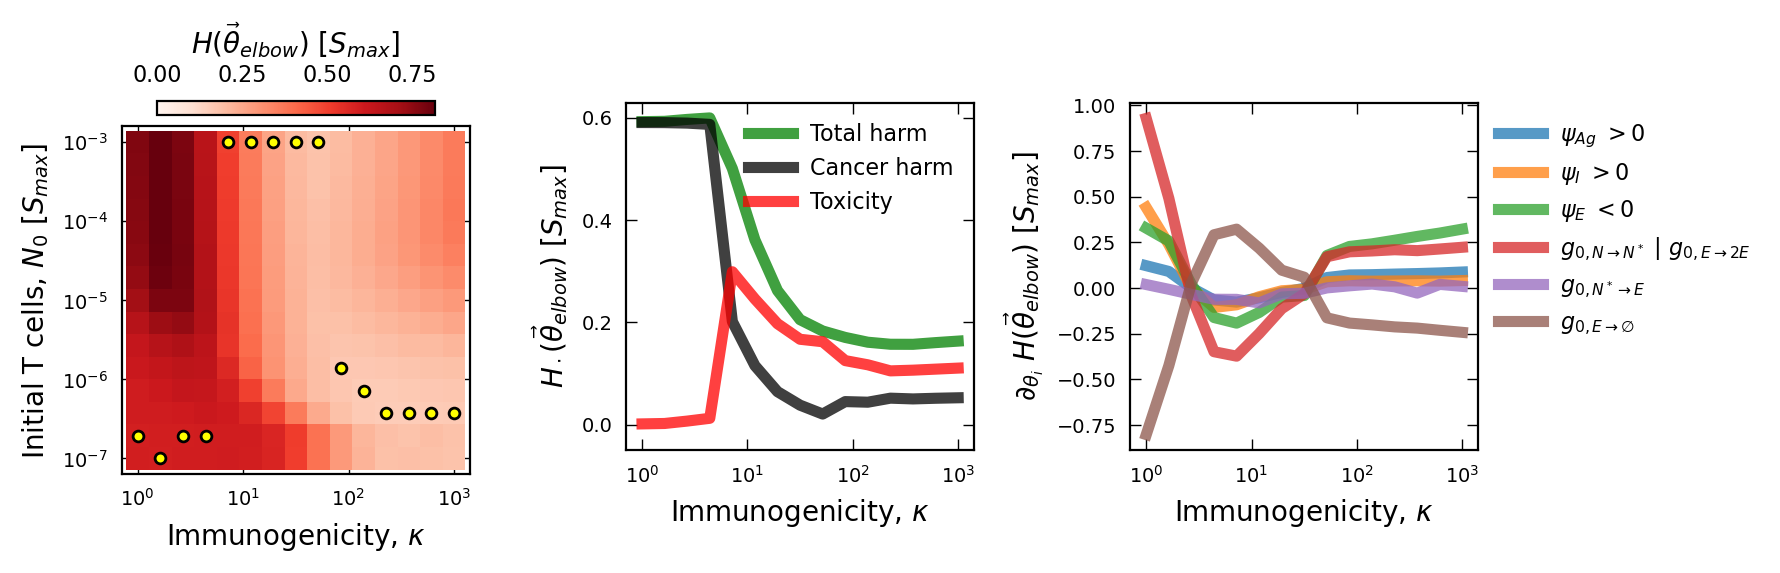

In [79]:
fig, axs = plt.subplots(1, 3, figsize=(8.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1000/num_pnts
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - modified_acute_pareto_reg), axis = 1) == 0]
im = axs[0].scatter(data['S_0'].values/data['K_I'].values,
                 data['N_0'].values/data['S_0'].values, #/data['S_0'].values,
                 marker = 's', s = size,
                 c = data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

axs[0].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['N_0'].values/opt_N0['S_0'].values, #/opt_N0['S_0'].values,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

# axs[0].fill_between(opt_N0['S_0'].values/opt_N0['K_I'].values, 
#                             np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
#                             np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
#                             alpha=0.2,
#                             color = cmap_colors[i])

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3]):
    axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
             opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = ['green', 'black', 'red'][j],
                label = ["Total harm", "Cancer harm", perf_labels[2]][j],
               **kwargs)

    # axs[1].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
    #      opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
    #      color = ['green', 'black', 'red'][j], label = ["Total harm", "Cancer harm", perf_labels[2]][j])

axs[1].set_ylabel(r"$H_\cdot(\vec\theta_{elbow})$ [$S_{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 8)

for i, var in enumerate(opt_vars_labels):
    axs[2].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                color = cmap_colors[i], 
                #linestyle = linestyles[i],
                label = opt_vars_labels[i]+((r'$~> 0$' if modified_acute_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                **kwargs)

    # axs[2].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
    #             gradients_data[:,i],
    #                label = opt_vars_labels[i]+((r'$~> 0$' if modified_acute_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
    #             color = cmap_colors[i])

#axs[2].text(1.25, 0.2, r'$N_0 =$ '+ str(np.round(fixed_N0.N_0.values[0]/S_0, 4)), fontsize=8)
axs[2].set_ylabel(r"$\partial_{\theta_i}$"+r" $H(\vec\theta_{elbow})$" +" [$S_{max}$]", fontsize = 10)
axs[2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=8)
#axs[2].set_ylim(-1.1*np.amax(np.abs(gradients_data)), 1.1*np.amax(np.abs(gradients_data)))
    

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"$H(\vec\theta_{elbow})$ [$S_{max}$]"
cb = fig.colorbar(im, ax=axs[0], location='top', shrink = 0.8, pad = 0.025)
cb.set_label(z_label, fontsize = 10)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.45, hspace=0.0)

plt.savefig('_figs/fig6_'+comment+'-reg-_compare_acute_prot_w_cancer_pareto_design'+'.pdf', format="pdf", transparent=True, dpi=300)

##### Compute tumour Harm of Ag. dominant pareto Harm with $K_S \sim K_I$

In [80]:
# run simulations with K_S ~ K_I
from optimize_nets import *
num_pnts = 15
runs = 10
K_S_sample = sample
K_S_sample[:,-1] = K_S_sample[:,1]

run(batch = [-1], outdir=d, inf_sample = K_S_sample, 
    comment="ag_dosage_scale_K_S_sim", runs = runs, infection_model = 'cancer', 
    default_reg = cancer_psis,
    num_cpu = num_cpu)

Running 40500 simulations in batch #-1
Saved sim_batch_-1-10-cancer-ag_dosage_scale_K_S_sim.pkl
0.3987548182408015 hrs


In [81]:
d_file = d + '/sim_batch_-1-10-cancer-ag_dosage_scale_K_S_sim.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(cancer_plots + reg, as_index=False).mean()

# compute infection harm without T cell response
cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])

In [82]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - modified_acute_pareto_reg), axis = 1) == 0]
opt_N0 = data.loc[data.groupby('K_I')['peff_total_harm'].idxmin()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))
fixed_N0 = data.loc[data.groupby('K_I')['N_0_match'].idxmin()].copy() #np.amax(data['N_0'])

# Compute effect of perturbation in the design
gradients = []
for k, (a,b) in enumerate(fixed_N0[['K_I', 'N_0']].values):
    input = cancer_acute_comp_df.loc[(cancer_acute_comp_df.K_I == a)*(cancer_acute_comp_df.N_0 == b)].copy()
    input.loc[:,'dummy'] = np.sum(np.abs(input.copy()[opt_vars[0:3] + reg_bl].values - modified_acute_pareto_reg), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        out[i] += grad[1]

    gradients.append(out)

gradients_data = np.vstack(gradients)

/tmp/ipykernel_38076/1932553009.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))


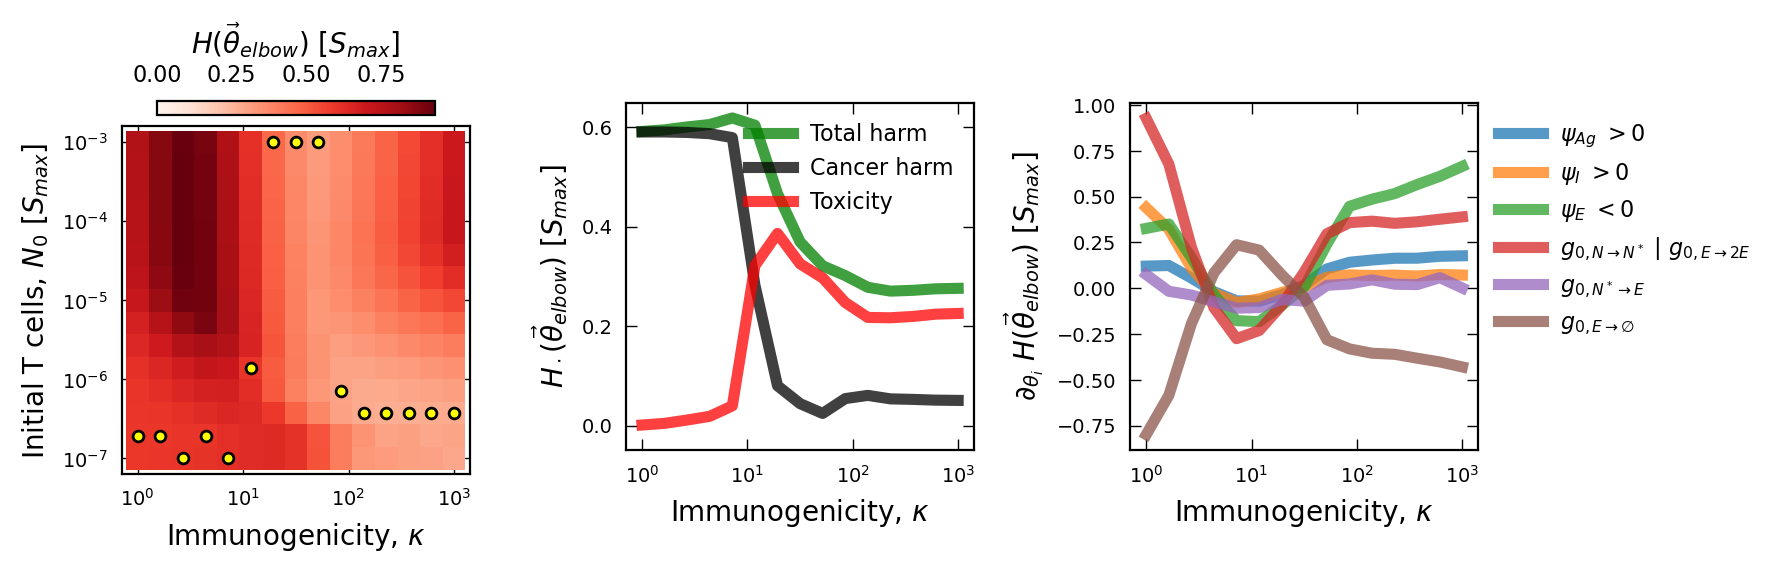

In [83]:
fig, axs = plt.subplots(1, 3, figsize=(8.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1000/num_pnts
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - modified_acute_pareto_reg), axis = 1) == 0]
im = axs[0].scatter(data['S_0'].values/data['K_I'].values,
                 data['N_0'].values/data['S_0'].values, #/data['S_0'].values,
                 marker = 's', s = size,
                 c = data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

axs[0].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['N_0'].values/opt_N0['S_0'].values, #/opt_N0['S_0'].values,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

# axs[0].fill_between(opt_N0['S_0'].values/opt_N0['K_I'].values, 
#                             np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
#                             np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
#                             alpha=0.2,
#                             color = cmap_colors[i])

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3]):
    axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
             opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = ['green', 'black', 'red'][j],
                label = ["Total harm", "Cancer harm", perf_labels[2]][j],
               **kwargs)

    # axs[1].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
    #      opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
    #      color = ['green', 'black', 'red'][j], label = ["Total harm", "Cancer harm", perf_labels[2]][j])

axs[1].set_ylabel(r"$H_\cdot(\vec\theta_{elbow})$ [$S_{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 8)

for i, var in enumerate(opt_vars_labels):
    axs[2].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                color = cmap_colors[i], 
                #linestyle = linestyles[i],
                label = opt_vars_labels[i]+((r'$~> 0$' if modified_acute_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                **kwargs)

    # axs[2].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
    #             gradients_data[:,i],
    #                label = opt_vars_labels[i]+((r'$~> 0$' if modified_acute_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
    #             color = cmap_colors[i])

#axs[2].text(1.25, 0.2, r'$N_0 =$ '+ str(np.round(fixed_N0.N_0.values[0]/S_0, 4)), fontsize=8)
axs[2].set_ylabel(r"$\partial_{\theta_i}$"+r" $H(\vec\theta_{elbow})$" +" [$S_{max}$]", fontsize = 10)
axs[2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=8)
#axs[2].set_ylim(-1.1*np.amax(np.abs(gradients_data)), 1.1*np.amax(np.abs(gradients_data)))
    

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"$H(\vec\theta_{elbow})$ [$S_{max}$]"
cb = fig.colorbar(im, ax=axs[0], location='top', shrink = 0.8, pad = 0.025)
cb.set_label(z_label, fontsize = 10)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.45, hspace=0.0)

plt.savefig('_figs/fig6_'+comment+'-reg-_compare_elbow_w_cancer_scale_K_S'+'.pdf', format="pdf", transparent=True, dpi=300)

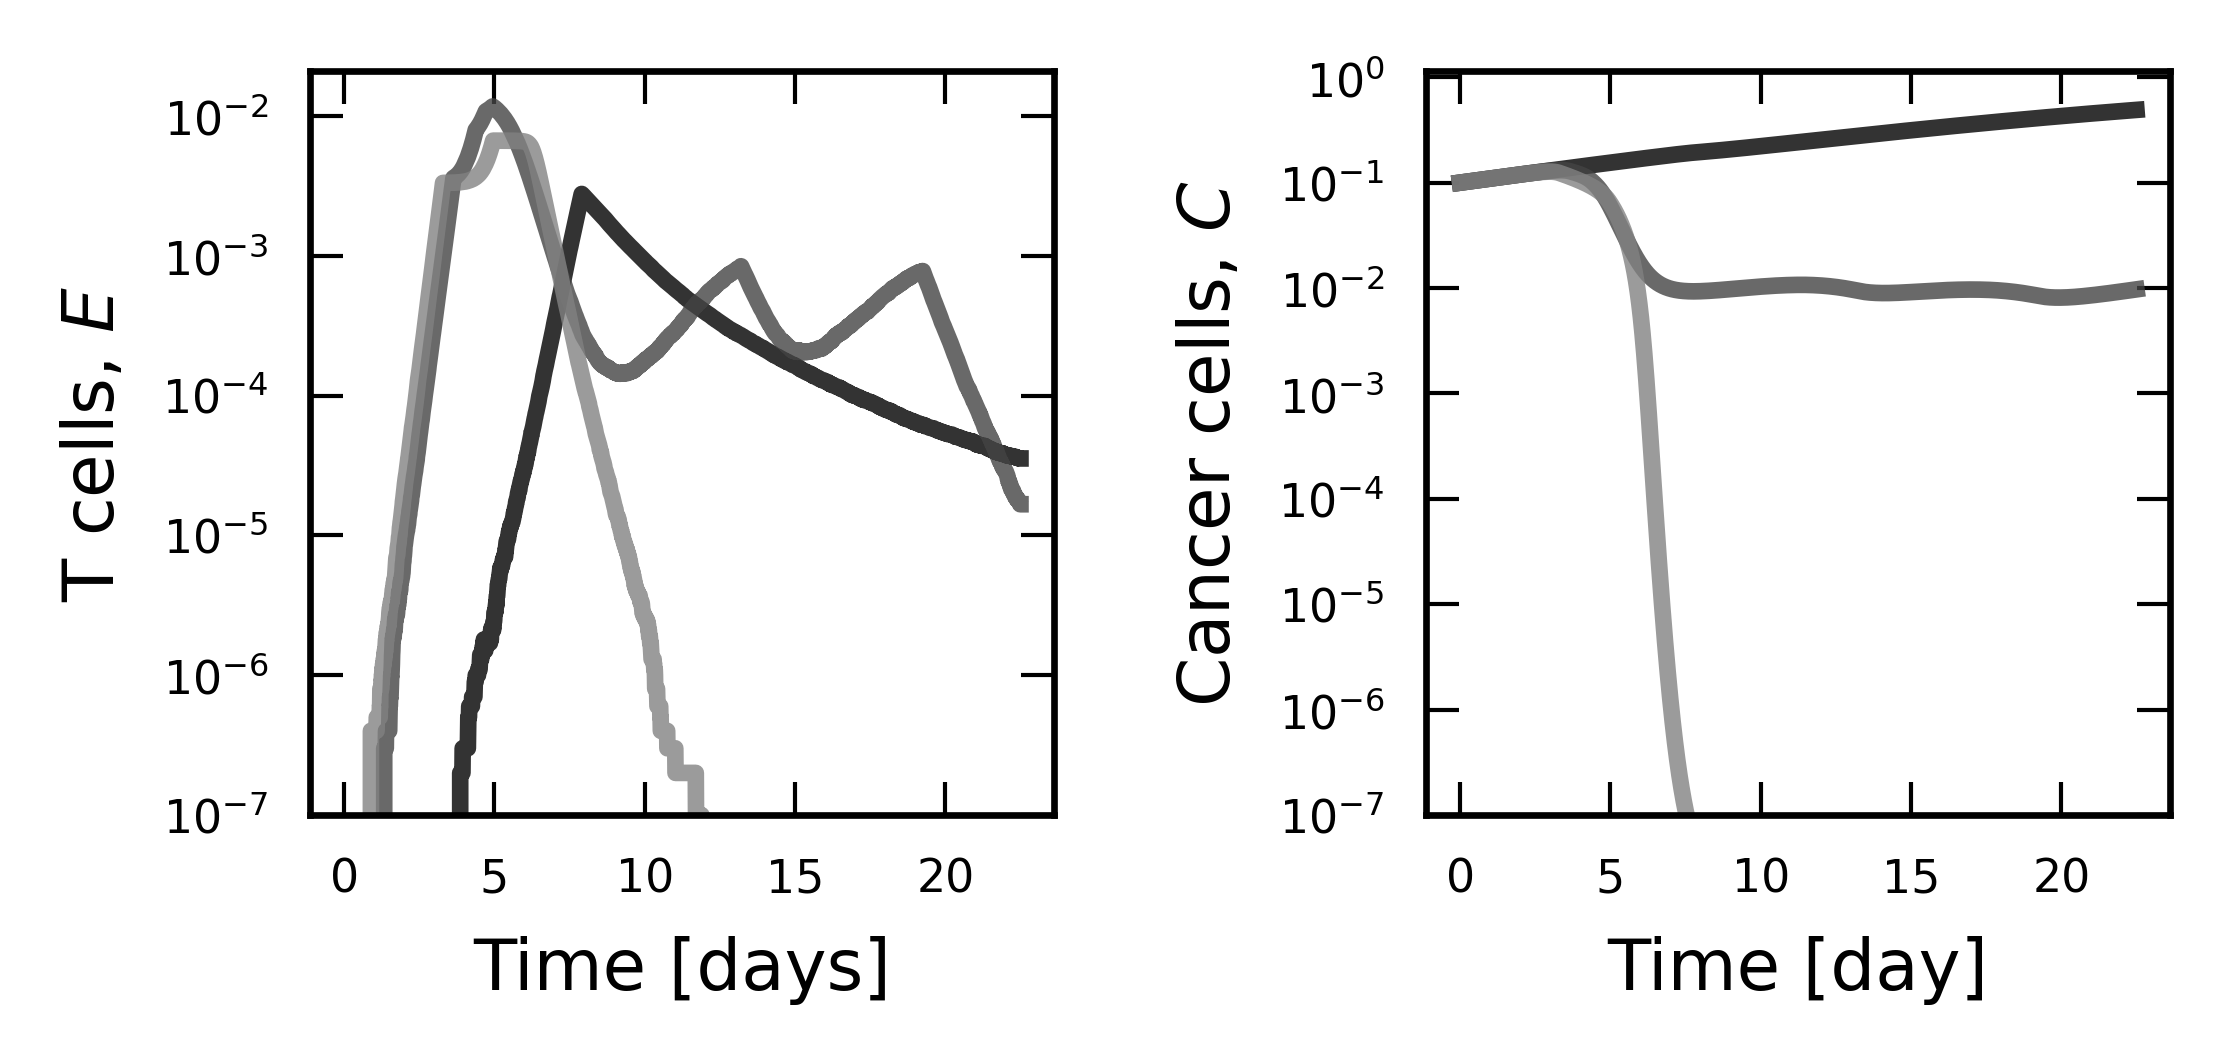

In [54]:
# Plot select infection responses
fig, axs = plt.subplots(1,2, dpi = 300, sharex = False, sharey = False, figsize=(4, 2))

sample = opt_N0[vir_vars].sort_values(by=cancer_plots[0], 
                                      ascending = [False]).values[[0, num_pnts // 2, -1],:]

store_runs = []
# Loop and do 
for k, v in enumerate(sample):

    feedback = p[-1]
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [acute_pareto_reg[0], acute_pareto_reg[1], acute_pareto_reg[2], acute_pareto_reg[4]],
                              activation_regulation = [acute_pareto_reg[0], acute_pareto_reg[1], acute_pareto_reg[2], acute_pareto_reg[3]],
                              contraction_regulation = [-acute_pareto_reg[0], -acute_pareto_reg[1], -acute_pareto_reg[2], acute_pareto_reg[5]],
                              infection_model = 'cancer',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 0.75*sim_duration,
                              steps = 1.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0].plot(ts, E/S_0, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)
    axs[1].plot(ts, I/S_0, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_0,)
    elif j == 1:
        ax.set_ylabel(r'Cancer cells, $C$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_0,)
    else:
        ax.set_xlabel("Immunogenicity", fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        #ax.set_yscale('symlog')
        # ax.semilogy()
        ax.semilogx()

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/figSI_'+comment+'-pareto-design-cancer_prot-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

Focusing on anti-inflammatory feedback, the optimal designs for acute response perform best with a treatment of high Immunogenicity and low dosage. What does this look like dynamically?

Fixing a pareto optimal network (with acute design) and varying one of the parameters we find that the biggest impact on performance in the biologically plausible range of inflammatory feedback comes from increasing/decreasing the inflammatory signal and/or the Naive to effector transition baseline. This suggests that if cancer can hide it's inflamatory signals it will be harder to clear.